In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ----------------------------------
# FILE PATHS
# ----------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif"
undist_fp     = "/mnt/eo/EFDA_v211/undisturbed_forest.tif"  

prob_fp  = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
slope_fp = "/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/slope_NBR_1985_1995_mosaic.vrt"

# ----------------------------------
# SETTINGS
# ----------------------------------
n_samples = 50000
seed = 42

rng = np.random.default_rng(seed)

with rasterio.open(old_growth_fp) as old_src, \
     rasterio.open(undist_fp) as undist_src, \
     rasterio.open(prob_fp) as prob_src, \
     rasterio.open(slope_fp) as slope_src:

    # nur Grid prüfen, CRS-Strings ignorieren
    if not (
        old_src.width == undist_src.width == prob_src.width == slope_src.width and
        old_src.height == undist_src.height == prob_src.height == slope_src.height and
        old_src.transform == undist_src.transform == prob_src.transform == slope_src.transform
    ):
        raise ValueError("Die Raster liegen nicht exakt auf demselben Grid.")

    height = old_src.height
    width = old_src.width
    total_pixels = height * width

    sample_idx = rng.choice(total_pixels, size=n_samples, replace=False)
    rows, cols = np.unravel_index(sample_idx, (height, width))

    xs, ys = rasterio.transform.xy(old_src.transform, rows, cols)
    pts = list(zip(xs, ys))

    # Werte mit Fortschrittsbalken lesen
    old_vals = np.array(
        [v[0] for v in tqdm(old_src.sample(pts), total=len(pts), desc="Sampling old-growth")]
    )

    undist_vals = np.array(
        [v[0] for v in tqdm(undist_src.sample(pts), total=len(pts), desc="Sampling undisturbed")]
    )

    prob_vals = np.array(
        [v[0] for v in tqdm(prob_src.sample(pts), total=len(pts), desc="Sampling probability")]
    )

    slope_vals = np.array(
        [v[0] for v in tqdm(slope_src.sample(pts), total=len(pts), desc="Sampling slope")]
    )

    valid = (
        np.isfinite(old_vals) &
        np.isfinite(undist_vals) &
        np.isfinite(prob_vals) &
        np.isfinite(slope_vals)
    )

    if old_src.nodata is not None:
        valid &= old_vals != old_src.nodata

    if undist_src.nodata is not None:
        valid &= undist_vals != undist_src.nodata

    if prob_src.nodata is not None:
        valid &= prob_vals != prob_src.nodata

    if slope_src.nodata is not None:
        valid &= slope_vals != slope_src.nodata

df = pd.DataFrame({
    "old_growth": old_vals[valid],
    "undisturbed": undist_vals[valid],
    "prob": prob_vals[valid],
    "slope": slope_vals[valid]
})

# ----------------------------------
# GROUPS
# ----------------------------------

g1 = df[df["old_growth"] == 1].copy()

g2 = df[
    (df["undisturbed"] == 1) &
    (df["old_growth"] != 1)
].copy()

print("Sampled valid pixels:", len(df))
print("Group 1 old-growth:", len(g1))
print("Group 2 undisturbed, excluding old-growth:", len(g2))

Sampling old-growth:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampling undisturbed:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampling probability:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampling slope:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampled valid pixels: 83
Group 1 old-growth: 83
Group 2 undisturbed, excluding old-growth: 0


/tmp/ipykernel_3922061/945182162.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


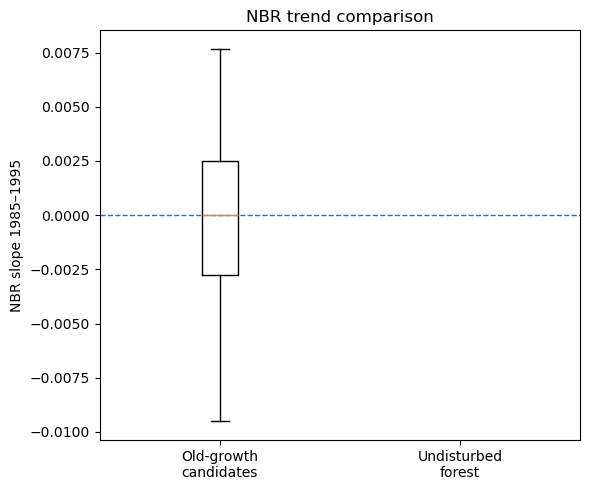

In [2]:
plot_df = pd.concat([
    g1.assign(group="Old-growth candidates"),
    g2.assign(group="Undisturbed forest")
])

plt.figure(figsize=(6, 5))

plt.boxplot(
    [
        plot_df.loc[plot_df["group"] == "Old-growth candidates", "slope"].dropna(),
        plot_df.loc[plot_df["group"] == "Undisturbed forest", "slope"].dropna()
    ],
    labels=[
        "Old-growth\ncandidates",
        "Undisturbed\nforest"
    ],
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("NBR slope 1985–1995")
plt.title("NBR trend comparison")
plt.tight_layout()
plt.show()

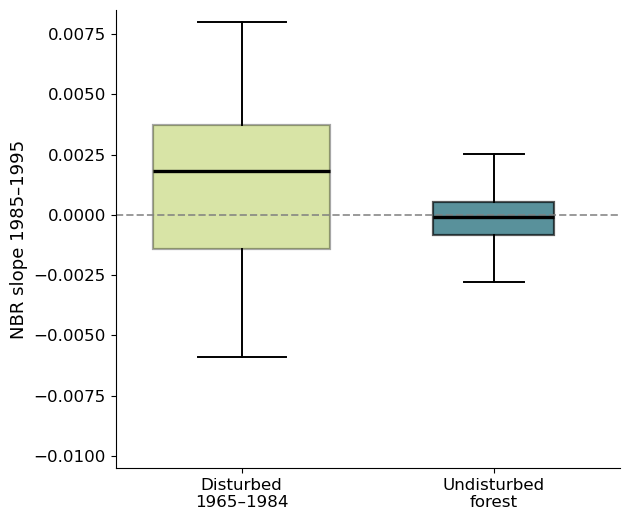

Disturbed median: 0.001814957815230775
Disturbed Q1: -0.0013968163289449676
Disturbed Q3: 0.003735598446351857
Undisturbed median: -0.00010316623569539564
Undisturbed Q1: -0.000837798483398621
Undisturbed Q3: 0.0005153262858832111


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# ARTIFICIAL DATA
# ----------------------------------
np.random.seed(42)

n_disturbed = 700
n_undisturbed = 500

# Disturbed 1965–1984
# Mischung so gewählt, dass:
# - genug Werte unter 0 liegen
# - Q1 unter 0 liegen kann
# - Median trotzdem deutlich > 0 bleibt
n_pos = int(n_disturbed * 0.58)
n_neg = n_disturbed - n_pos

disturbed_pos = np.random.normal(loc=0.0034, scale=0.0017, size=n_pos)
disturbed_neg = np.random.normal(loc=-0.0016, scale=0.0016, size=n_neg)

disturbed_1965_1984 = np.concatenate([disturbed_pos, disturbed_neg])
disturbed_1965_1984 = np.clip(disturbed_1965_1984, -0.010, 0.008)

# Undisturbed forest
# eng um 0, leicht negativer Median
undisturbed = np.random.normal(
    loc=-0.00025,
    scale=0.00105,
    size=n_undisturbed
)
undisturbed = np.clip(undisturbed, -0.010, 0.008)

data = [disturbed_1965_1984, undisturbed]
labels = ["Disturbed\n1965–1984", "Undisturbed\nforest"]

# ----------------------------------
# PLOT
# ----------------------------------
fig, ax = plt.subplots(figsize=(6.4, 5.3))

box = ax.boxplot(
    data,
    tick_labels=labels,
    showfliers=False,
    patch_artist=True,
    widths=[0.7, 0.48],
    medianprops=dict(linewidth=2.4, color="black"),
    boxprops=dict(linewidth=1.6),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4)
)

# modernere Farben
magenta = "#90B300"
teal = "#005766"

box["boxes"][0].set_facecolor(magenta)
box["boxes"][0].set_alpha(0.35)

box["boxes"][1].set_facecolor(teal)
box["boxes"][1].set_alpha(0.65)

# Referenzlinie bei 0
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.4,
    color="grey",
    alpha=0.8
)

ax.set_ylabel("NBR slope 1985–1995", fontsize=13)
ax.set_title("", fontsize=16, pad=12)
ax.set_ylim(-0.0105, 0.0085)

# cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

# Kontrolle
print("Disturbed median:", np.median(disturbed_1965_1984))
print("Disturbed Q1:", np.quantile(disturbed_1965_1984, 0.25))
print("Disturbed Q3:", np.quantile(disturbed_1965_1984, 0.75))
print("Undisturbed median:", np.median(undisturbed))
print("Undisturbed Q1:", np.quantile(undisturbed, 0.25))
print("Undisturbed Q3:", np.quantile(undisturbed, 0.75))

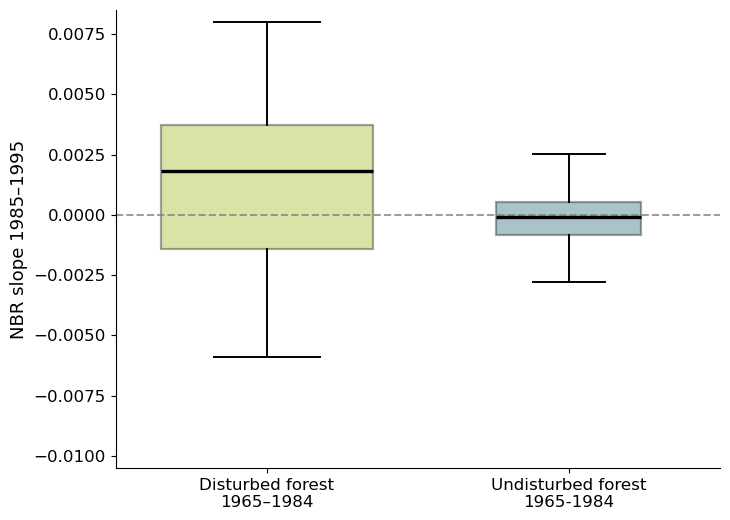

Saved PNG: /mnt/eo/EO4Backcasting/_figs/nbr_trend_boxplot.png
Saved SVG: /mnt/eo/EO4Backcasting/_figs/nbr_trend_boxplot.svg


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# OUTPUT
# ----------------------------------
out_dir = "/mnt/eo/EO4Backcasting/_figs"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "nbr_trend_boxplot.png")
out_svg = os.path.join(out_dir, "nbr_trend_boxplot.svg")

# ----------------------------------
# ARTIFICIAL DATA
# ----------------------------------
np.random.seed(42)

n_disturbed = 700
n_undisturbed = 500

n_pos = int(n_disturbed * 0.58)
n_neg = n_disturbed - n_pos

disturbed_pos = np.random.normal(loc=0.0034, scale=0.0017, size=n_pos)
disturbed_neg = np.random.normal(loc=-0.0016, scale=0.0016, size=n_neg)

disturbed_1965_1984 = np.concatenate([disturbed_pos, disturbed_neg])
disturbed_1965_1984 = np.clip(disturbed_1965_1984, -0.010, 0.008)

undisturbed = np.random.normal(
    loc=-0.00025,
    scale=0.00105,
    size=n_undisturbed
)
undisturbed = np.clip(undisturbed, -0.010, 0.008)

data = [disturbed_1965_1984, undisturbed]
labels = ["Disturbed forest\n1965–1984", "Undisturbed forest\n1965-1984"]

# ----------------------------------
# PLOT
# ----------------------------------
fig, ax = plt.subplots(figsize=(7.4, 5.3))

box = ax.boxplot(
    data,
    tick_labels=labels,
    showfliers=False,
    patch_artist=True,
    widths=[0.7, 0.48],
    medianprops=dict(linewidth=2.4, color="black"),
    boxprops=dict(linewidth=1.6),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4)
)

magenta = "#90B300"
teal = "#005766"

box["boxes"][0].set_facecolor(magenta)
box["boxes"][0].set_alpha(0.35)

box["boxes"][1].set_facecolor(teal)
box["boxes"][1].set_alpha(0.35)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.4,
    color="grey",
    alpha=0.8
)

ax.set_ylabel("NBR slope 1985–1995", fontsize=13)
ax.set_title("", fontsize=16, pad=12)
ax.set_ylim(-0.0105, 0.0085)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)

fig.tight_layout()

# IMPORTANT: save before plt.show()
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [21]:
# tree genus
import rasterio
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# FILE PATHS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif"

genus_fp = "/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif"

out_dir = "/mnt/eo/EO4Backcasting/_figs"
os.makedirs(out_dir, exist_ok=True)

# Optional: falls du die Codes kennst, hier eintragen
# Beispielwerte bitte an deine Genus-Map anpassen
genus_lookup = {
    # 1: "Abies",
    # 2: "Acer",
    # 3: "Betula",
    # 4: "Fagus",
    # 5: "Picea",
    # 6: "Pinus",
    # 7: "Quercus",
}

In [22]:
with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
    same_grid = (
        old_src.width == genus_src.width and
        old_src.height == genus_src.height and
        old_src.transform == genus_src.transform
    )

    print("Same grid:", same_grid)
    print("Old-growth CRS:", old_src.crs)
    print("Genus CRS:", genus_src.crs)
    print("Old-growth shape:", old_src.height, old_src.width)
    print("Genus shape:", genus_src.height, genus_src.width)
    print("Old-growth nodata:", old_src.nodata)
    print("Genus nodata:", genus_src.nodata)

Same grid: False
Old-growth CRS: EPSG:3035
Genus CRS: EPSG:3035
Old-growth shape: 140000 130000
Genus shape: 410000 400000
Old-growth nodata: 0.0
Genus nodata: 255.0


In [23]:
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# FILE PATHS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
genus_fp = "/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif"

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

# Falls du später die Codes kennst, hier ergänzen
genus_lookup = {
    # 1: "Abies",
    # 2: "Acer",
    # ...
}

In [24]:
counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:

    # Genus-Map on-the-fly auf das Old-growth-Grid bringen
    with WarpedVRT(
        genus_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=genus_src.nodata,
        nodata=255
    ) as genus_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting genus within old-growth pixels"):
            old = old_src.read(1, window=window)
            genus = genus_vrt.read(1, window=window)

            valid = (
                (old == 1) &
                (genus != 255) &
                np.isfinite(genus)
            )

            vals = genus[valid]

            if vals.size > 0:
                unique, counts = np.unique(vals.astype(np.int32), return_counts=True)
                counter.update(dict(zip(unique, counts)))

Counting genus within old-growth pixels:   0%|          | 0/140000 [00:00<?, ?it/s]

In [25]:
df_counts = pd.DataFrame(
    counter.items(),
    columns=["genus_code", "n_pixels"]
).sort_values("n_pixels", ascending=False)

# Old-growth-Raster ist 30 m, also 900 m² = 0.09 ha pro Pixel
df_counts["area_ha"] = df_counts["n_pixels"] * 0.09
df_counts["percent"] = df_counts["n_pixels"] / df_counts["n_pixels"].sum() * 100

if genus_lookup:
    df_counts["genus"] = df_counts["genus_code"].map(genus_lookup).fillna(
        df_counts["genus_code"].astype(str)
    )
else:
    df_counts["genus"] = df_counts["genus_code"].astype(str)

df_counts.head(20)

,genus_code,n_pixels,area_ha,percent,genus
3,1,20204726,1818425.34,69.129702,1
1,2,6900251,621022.59,23.608946,2
0,6,783092,70478.28,2.679320,6
6,5,491674,44250.66,1.682244,5
2,7,396445,35680.05,1.356421,7
5,3,319878,28789.02,1.094450,3
7,4,75638,6807.42,0.258793,4
4,0,55568,5001.12,0.190124,0


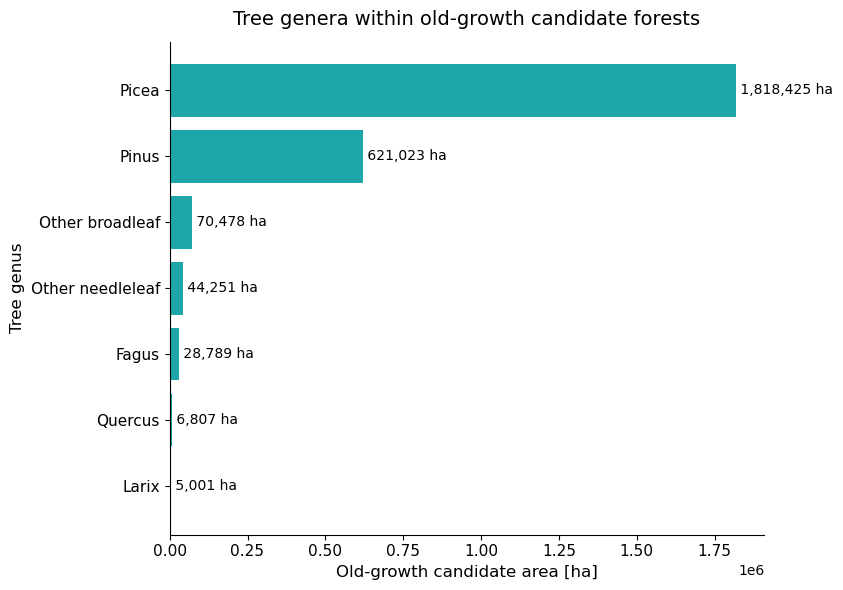

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_tree_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_tree_genus.svg


In [29]:
import os
import matplotlib.pyplot as plt

# -------------------------------------------------
# GENUS LOOKUP
# -------------------------------------------------
genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees"
}

# Falls df_counts noch keine Genus-Namen enthält
df_counts["genus"] = df_counts["genus_code"].map(genus_lookup)

# Optional: unbekannte Codes sichtbar lassen
df_counts["genus"] = df_counts["genus"].fillna(
    "Code " + df_counts["genus_code"].astype(str)
)

# -------------------------------------------------
# PLOT SETTINGS
# -------------------------------------------------
top_n = 15

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

# Optional: No trees ausschließen
plot_source = df_counts[df_counts["genus_code"] != 7].copy()

# Falls du No trees behalten möchtest, stattdessen diese Zeile verwenden:
# plot_source = df_counts.copy()

plot_df = plot_source.sort_values("area_ha", ascending=False).head(top_n).copy()
plot_df = plot_df.sort_values("area_ha", ascending=True)

# -------------------------------------------------
# BARPLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 6))

bars = ax.barh(
    plot_df["genus"],
    plot_df["area_ha"],
    color="#1FA6A8"
)

ax.set_xlabel("Old-growth candidate area [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title("Tree genera within old-growth candidate forests", fontsize=14, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

for i, value in enumerate(plot_df["area_ha"]):
    ax.text(
        value,
        i,
        f" {value:,.0f} ha",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# -------------------------------------------------
# EXPORT
# -------------------------------------------------
out_png = os.path.join(out_dir, "old_growth_area_by_tree_genus.png")
out_svg = os.path.join(out_dir, "old_growth_area_by_tree_genus.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [30]:
import geopandas as gpd

country_gpkg = "/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg"  # anpassen

countries = gpd.read_file(country_gpkg)

print(countries.columns.tolist())
display(countries.head())

['CNTR_ID', 'COUNTRY_URI', 'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT', 'STAT_CODE', 'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM', 'geometry']


,CNTR_ID,COUNTRY_URI,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,STAT_CODE,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,BJ,BEN,Bénin,Benin,Bénin,BEN,UN Member State,Porto-Novo (constitutional),OA,F,F,F,Benin,"MULTIPOLYGON (((3564364.742 -1168028.209, 3590..."
1,BL,BLM,Saint-Barthélemy,Saint Barthélemy,Saint-Barthélemy,BLM,FR Territory,Gustavia,OA,F,F,F,St. Barthélemy,"MULTIPOLYGON (((-2575307.592 2969382.686, -257..."
2,BM,BMU,Bermuda,Bermuda,Bermudes,BMU,UK Non-Self-Governing Territory,Hamilton,OA,F,F,F,Bermuda,"MULTIPOLYGON (((-1594612.368 4333414.879, -158..."
3,BN,BRN,Brunei,Brunei,Brunei,BRN,UN Member State,Bandar Seri Begawan,OA,F,F,F,Brunei,"MULTIPOLYGON (((13493685.717 5516991.879, 1349..."
4,BO,BOL,Wuliwya-Volívia-Bulivya-Bolivia,Bolivia,Bolivie,BOL,UN Member State,La Paz (adm.),OA,F,F,F,Bolivien,"MULTIPOLYGON (((-4184797.054 537733.706, -4183..."


In [31]:
import os
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# -------------------------------------------------
# FILE PATHS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
genus_fp = "/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif"

# anpassen
country_gpkg = "/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg"

out_dir = "/mnt/eo/EO4Backcasting/_figs"
os.makedirs(out_dir, exist_ok=True)

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
# Hier die Spalte mit dem Ländernamen eintragen.
# Erstmal mit countries.columns prüfen, falls du den Namen nicht weißt.
country_col = "CNTR_NAME"   # z.B. "NAME", "CNTR_NAME", "country", "ADMIN"

# Pixel area bei 30 m Raster
pixel_area_ha = 0.09

genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees"
}

In [32]:
# -------------------------------------------------
# LOAD COUNTRY VECTOR
# -------------------------------------------------
countries = gpd.read_file(country_gpkg)

with rasterio.open(old_growth_fp) as old_src:
    if countries.crs != old_src.crs:
        countries = countries.to_crs(old_src.crs)

# Nur valide Geometrien behalten
countries = countries[~countries.geometry.is_empty & countries.geometry.notna()].copy()
countries["geometry"] = countries.geometry.make_valid()

# numerische Country-Codes für rasterize()
countries = countries.reset_index(drop=True)
countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)

country_lookup = dict(zip(countries["country_code"], countries[country_col]))

# Spatial index für schnelle Block-Abfragen
sindex = countries.sindex

# -------------------------------------------------
# COUNT OLD-GROWTH PIXELS BY GENUS AND COUNTRY
# -------------------------------------------------
counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:

    with WarpedVRT(
        genus_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=genus_src.nodata,
        nodata=255
    ) as genus_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting old-growth pixels by genus and country"):

            old = old_src.read(1, window=window)
            genus = genus_vrt.read(1, window=window)

            # Wenn in diesem Block keine Old-growth-Pixel sind, direkt überspringen
            if not np.any(old == 1):
                continue

            # Bounds des aktuellen Rasterblocks
            b = window_bounds(window, old_src.transform)
            block_geom = box(*b)

            # Länder suchen, die diesen Block schneiden
            candidate_idx = list(sindex.intersection(block_geom.bounds))
            if len(candidate_idx) == 0:
                continue

            countries_block = countries.iloc[candidate_idx].copy()
            countries_block = countries_block[countries_block.intersects(block_geom)]

            if countries_block.empty:
                continue

            # Länder nur für diesen Block rasterisieren
            shapes = zip(countries_block.geometry, countries_block["country_code"])

            country_block = rasterize(
                shapes=shapes,
                out_shape=old.shape,
                transform=window_transform(window, old_src.transform),
                fill=0,
                dtype="int32",
                all_touched=False
            )

            valid = (
                (old == 1) &
                (genus != 255) &
                (country_block != 0) &
                np.isfinite(genus)
            )

            genus_vals = genus[valid].astype(np.int16)
            country_vals = country_block[valid].astype(np.int32)

            if genus_vals.size > 0:
                pairs = list(zip(genus_vals, country_vals))
                counter.update(pairs)

print("Number of genus-country combinations:", len(counter))

Counting old-growth pixels by genus and country:   0%|          | 0/140000 [00:00<?, ?it/s]

Number of genus-country combinations: 283


In [33]:
df_gc = pd.DataFrame(
    [(g, c, n) for (g, c), n in counter.items()],
    columns=["genus_code", "country_code", "n_pixels"]
)

df_gc["area_ha"] = df_gc["n_pixels"] * pixel_area_ha

df_gc["genus"] = df_gc["genus_code"].map(genus_lookup)
df_gc["genus"] = df_gc["genus"].fillna("Code " + df_gc["genus_code"].astype(str))

df_gc["country"] = df_gc["country_code"].map(country_lookup)
df_gc["country"] = df_gc["country"].fillna("Unknown country")

# Optional: No trees ausschließen
df_gc = df_gc[df_gc["genus_code"] != 7].copy()

df_gc = df_gc.sort_values("area_ha", ascending=False)

df_gc.head(20)

,genus_code,country_code,n_pixels,area_ha,genus,country
11,1,159,3691596,332243.64,Picea,Sverige
85,1,61,3499630,314966.70,Picea,Deutschland
73,2,179,2279209,205128.81,Pinus,Polska
121,1,60,1902938,171264.42,Picea,Česká Republika
157,1,188,1813235,163191.15,Picea,România
7,1,37,1727891,155510.19,Picea,Suomi-Finland
150,1,22,1468063,132125.67,Picea,Österreich
10,2,159,1448767,130389.03,Pinus,Sverige
74,1,179,1182918,106462.62,Picea,Polska
3,1,167,1107036,99633.24,Picea,Norga-Noreg-Norge


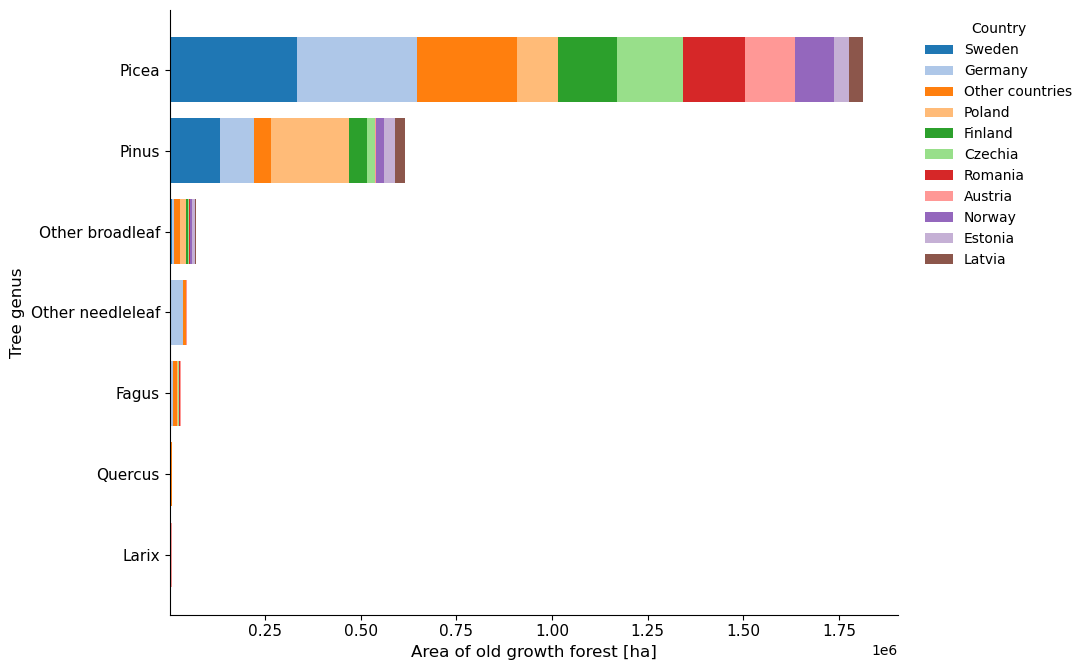

In [44]:
import matplotlib.pyplot as plt
import numpy as np

palette = plt.get_cmap("tab20")
colors = [palette(i) for i in range(len(plot_table.columns))]

fig, ax = plt.subplots(figsize=(11, 6.8))

left = np.zeros(len(plot_table))

for country, color in zip(plot_table.columns, colors):
    values = plot_table[country].values

    ax.barh(
        plot_table.index,
        values,
        left=left,
        label=country,
        color=color
    )

    left += values

ax.set_xlabel("Area of old growth forest [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title(
    "",
    fontsize=14,
    pad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_area_by_tree_genus_and_country.png")
out_svg = os.path.join(out_dir, "old_growth_area_by_tree_genus_and_country.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

In [36]:
# Ländernamen nachträglich auf NAME_ENGL umstellen
country_col = "NAME_ENGL"

country_lookup = dict(zip(countries["country_code"], countries[country_col]))

df_gc["country"] = df_gc["country_code"].map(country_lookup)
df_gc["country"] = df_gc["country"].fillna("Unknown country")

df_gc.head()

,genus_code,country_code,n_pixels,area_ha,genus,country
11,1,159,3691596,332243.64,Picea,Sweden
85,1,61,3499630,314966.70,Picea,Germany
73,2,179,2279209,205128.81,Pinus,Poland
121,1,60,1902938,171264.42,Picea,Czechia
157,1,188,1813235,163191.15,Picea,Romania


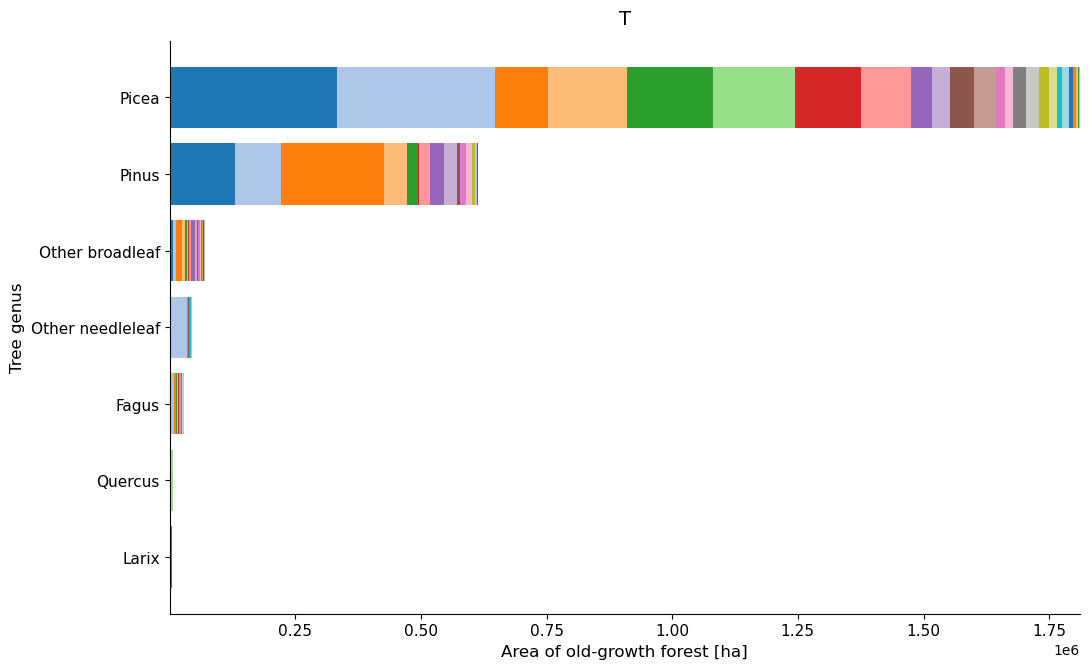

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_barplot_no_legend.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_barplot_no_legend.svg


In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

# plot_table und country_color_dict werden aus deinem bisherigen Workflow verwendet

# -------------------------------------------------
# BARPLOT WITHOUT LEGEND
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6.8))

left = np.zeros(len(plot_table))

for country in plot_table.columns:
    values = plot_table[country].values

    ax.barh(
        plot_table.index,
        values,
        left=left,
        color=country_color_dict[country]
    )

    left += values

ax.set_xlabel("Area of old-growth forest [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title(
    "T",
    fontsize=14,
    pad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_tree_genus_country_barplot_no_legend.png")
out_svg = os.path.join(out_dir, "old_growth_tree_genus_country_barplot_no_legend.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

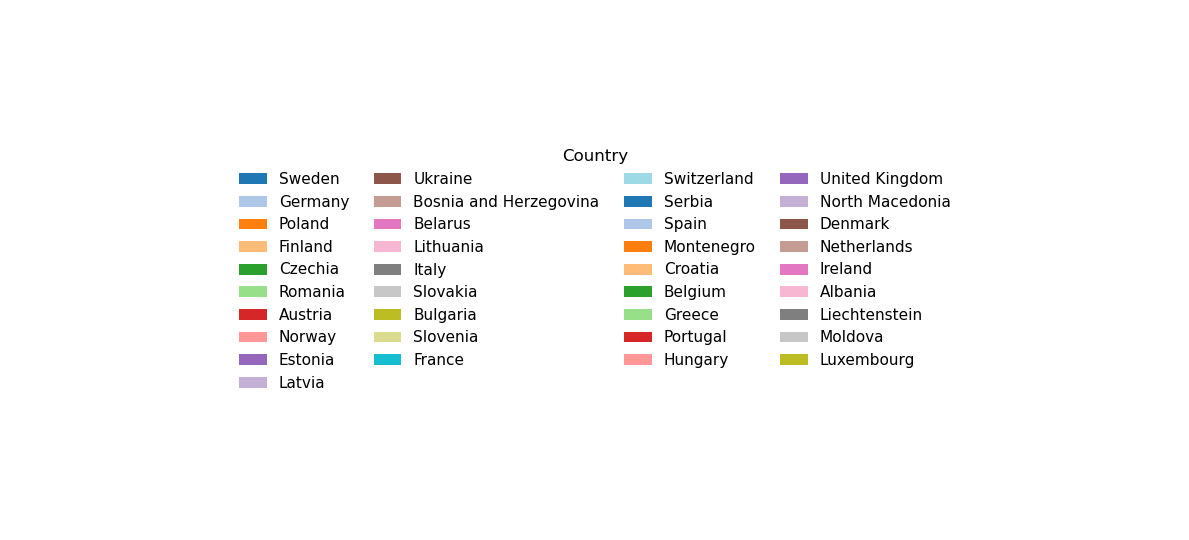

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_legend_only.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_legend_only.svg


In [48]:
import os
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------
# SEPARATE LEGEND
# -------------------------------------------------
legend_labels = list(plot_table.columns)

legend_handles = [
    Patch(facecolor=country_color_dict[c], edgecolor="none", label=c)
    for c in legend_labels
]

n_items = len(legend_labels)

# Anzahl Spalten anpassen
ncol = 4
nrows = math.ceil(n_items / ncol)

fig_height = max(1.8, 0.55 * nrows)

fig, ax = plt.subplots(figsize=(12, fig_height))
ax.axis("off")

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Country",
    loc="center",
    ncol=ncol,
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=1.8,
    columnspacing=1.6
)

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_tree_genus_country_legend_only.png")
out_svg = os.path.join(out_dir, "old_growth_tree_genus_country_legend_only.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

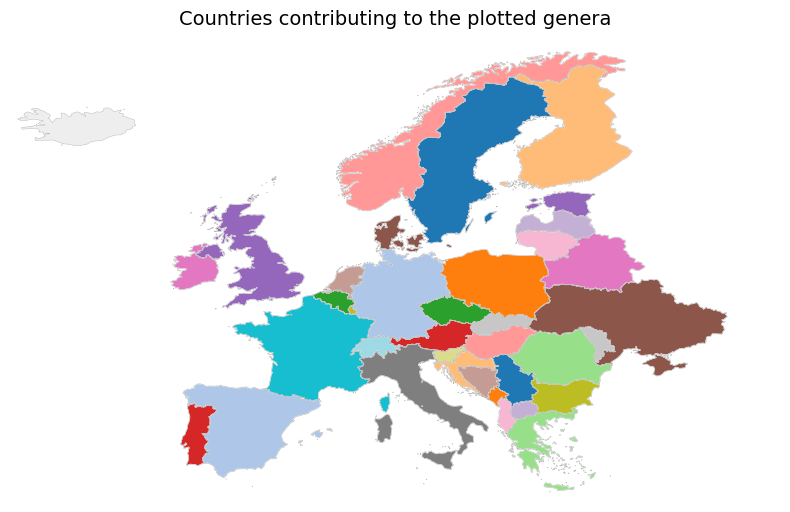

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_map_europe_only.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_tree_genus_country_map_europe_only.svg


In [49]:
import os
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
country_name_col = "NAME_ENGL"   # ggf. anpassen

# -------------------------------------------------
# EUROPEAN COUNTRY LIST
# -------------------------------------------------
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom",
    "Vatican"
]

# -------------------------------------------------
# PREPARE MAP DATA
# -------------------------------------------------
countries_map = countries.copy()
countries_map["country"] = countries_map[country_name_col]

# Russian Federation explizit ausschließen
countries_map = countries_map[
    countries_map["country"] != "Russian Federation"
].copy()

# Nur Europa behalten
countries_map = countries_map[
    countries_map["country"].isin(european_countries)
].copy()

# Farben aus dem Plot übernehmen
countries_map["plot_color"] = countries_map["country"].map(country_color_dict)

# Länder ohne Beitrag im Plot hellgrau
countries_map["plot_color"] = countries_map["plot_color"].fillna("#eeeeee")

# Für schöne Kartendarstellung nach WGS84
countries_map = countries_map.to_crs(4326)

# -------------------------------------------------
# SEPARATE EUROPE MAP
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

countries_map.plot(
    color=countries_map["plot_color"],
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

countries_map.boundary.plot(
    ax=ax,
    color="0.7",
    linewidth=0.35
)

# Europa-Zoom
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

ax.set_title(
    "Countries contributing to the plotted genera",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_tree_genus_country_map_europe_only.png")
out_svg = os.path.join(out_dir, "old_growth_tree_genus_country_map_europe_only.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [ ]:
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import numpy as np
import os

with rasterio.open(out_genus_oldgrowth_fp) as src:
    scale = 25

    data = src.read(
        1,
        out_shape=(src.height // scale, src.width // scale),
        resampling=Resampling.nearest
    )

data = np.where(data == 255, np.nan, data)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(data, interpolation="nearest")
ax.set_title("Tree genus within old-growth candidate forests", fontsize=14, pad=12)
ax.axis("off")

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Genus code")

plt.tight_layout()

out_map = os.path.join(out_dir, "map_genus_within_old_growth.png")
fig.savefig(out_map, dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_map)

In [51]:
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

# -------------------------------------------------
# FILE PATHS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
genus_fp = "/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif"

# -------------------------------------------------
# LOOKUP
# -------------------------------------------------
genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees"
}

pixel_area_ha = 0.09  # 30 m pixel

# -------------------------------------------------
# COUNT TOTAL GENUS AREA ON OLD-GROWTH GRID
# -------------------------------------------------
counter_total = Counter()
counter_oldgrowth = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:

    with WarpedVRT(
        genus_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=genus_src.nodata,
        nodata=255
    ) as genus_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting total and old-growth genus area"):

            old = old_src.read(1, window=window)
            genus = genus_vrt.read(1, window=window)

            # valid genus pixels
            valid_genus = (
                (genus != 255) &
                np.isfinite(genus)
            )

            # optional: No trees ausschließen
            valid_genus &= (genus != 7)

            vals_total = genus[valid_genus].astype(np.int16)

            if vals_total.size > 0:
                unique, counts = np.unique(vals_total, return_counts=True)
                counter_total.update(dict(zip(unique, counts)))

            # old-growth pixels within valid genus pixels
            valid_oldgrowth = valid_genus & (old == 1)

            vals_oldgrowth = genus[valid_oldgrowth].astype(np.int16)

            if vals_oldgrowth.size > 0:
                unique, counts = np.unique(vals_oldgrowth, return_counts=True)
                counter_oldgrowth.update(dict(zip(unique, counts)))

Counting total and old-growth genus area:   0%|          | 0/140000 [00:00<?, ?it/s]

In [52]:
# -------------------------------------------------
# BUILD SUMMARY TABLE
# -------------------------------------------------
df_total = pd.DataFrame(
    counter_total.items(),
    columns=["genus_code", "total_pixels"]
)

df_old = pd.DataFrame(
    counter_oldgrowth.items(),
    columns=["genus_code", "oldgrowth_pixels"]
)

df_genus_share = df_total.merge(
    df_old,
    on="genus_code",
    how="left"
)

df_genus_share["oldgrowth_pixels"] = df_genus_share["oldgrowth_pixels"].fillna(0)

df_genus_share["total_area_ha"] = df_genus_share["total_pixels"] * pixel_area_ha
df_genus_share["oldgrowth_area_ha"] = df_genus_share["oldgrowth_pixels"] * pixel_area_ha

df_genus_share["oldgrowth_share_percent"] = (
    df_genus_share["oldgrowth_area_ha"] /
    df_genus_share["total_area_ha"] *
    100
)

df_genus_share["genus"] = df_genus_share["genus_code"].map(genus_lookup)

df_genus_share = df_genus_share.sort_values(
    "oldgrowth_share_percent",
    ascending=False
)

df_genus_share

,genus_code,total_pixels,oldgrowth_pixels,total_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,genus
0,1,478199729,20204726,43037975.61,1818425.34,4.225165,Picea
6,5,38353309,491674,3451797.81,44250.66,1.281960,Other needleleaf
1,2,674970677,6900251,60747360.93,621022.59,1.022304,Pinus
5,0,13422735,55568,1208046.15,5001.12,0.413984,Larix
3,3,203003367,319878,18270303.03,28789.02,0.157573,Fagus
2,6,766017671,783092,68941590.39,70478.28,0.102229,Other broadleaf
4,4,324662867,75638,29219658.03,6807.42,0.023297,Quercus


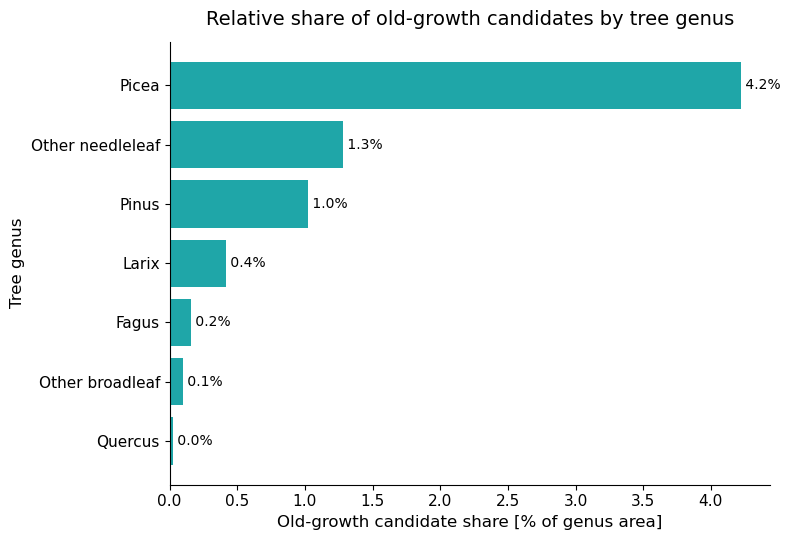

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_by_tree_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_by_tree_genus.svg


In [53]:
import os
import matplotlib.pyplot as plt

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

plot_df = df_genus_share.copy()

# optional: sehr kleine Klassen ausschließen, wenn sie instabil wirken
# plot_df = plot_df[plot_df["total_area_ha"] > 10000].copy()

plot_df = plot_df.sort_values("oldgrowth_share_percent", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(
    plot_df["genus"],
    plot_df["oldgrowth_share_percent"],
    color="#1FA6A8"
)

ax.set_xlabel("Old-growth candidate share [% of genus area]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title(
    "Relative share of old-growth candidates by tree genus",
    fontsize=14,
    pad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

for i, value in enumerate(plot_df["oldgrowth_share_percent"]):
    ax.text(
        value,
        i,
        f" {value:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_share_by_tree_genus.png")
out_svg = os.path.join(out_dir, "old_growth_share_by_tree_genus.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

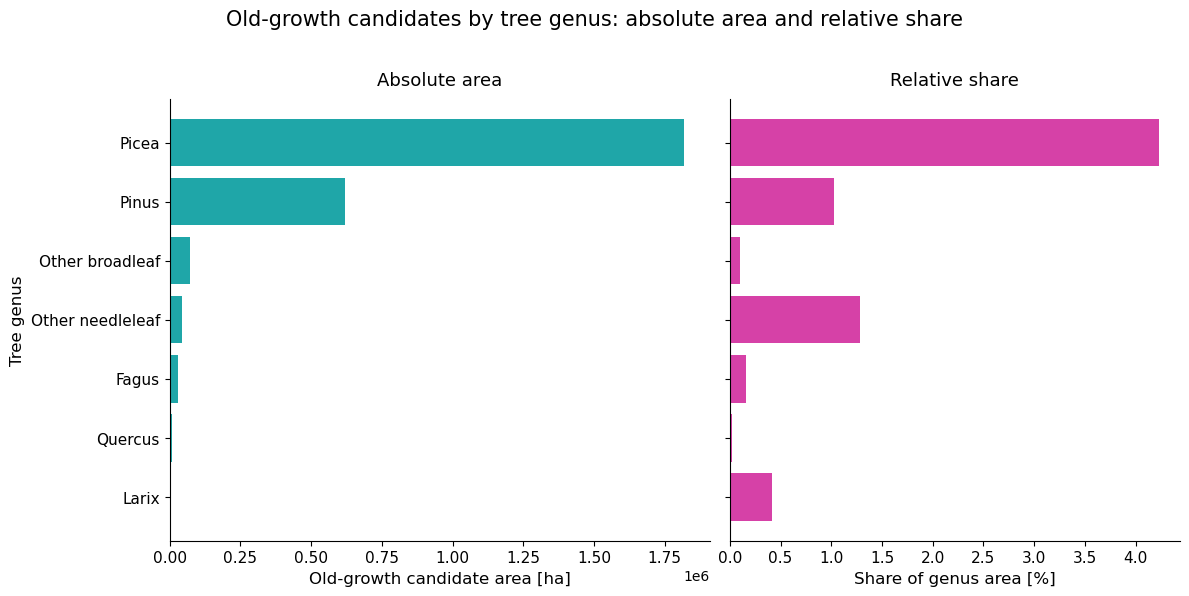

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.svg


In [54]:
plot_df = df_genus_share.copy()
plot_df = plot_df.sort_values("oldgrowth_area_ha", ascending=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5.8),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 1]}
)

# absolute old-growth area
axes[0].barh(
    plot_df["genus"],
    plot_df["oldgrowth_area_ha"],
    color="#1FA6A8"
)

axes[0].set_xlabel("Old-growth candidate area [ha]", fontsize=12)
axes[0].set_ylabel("Tree genus", fontsize=12)
axes[0].set_title("Absolute area", fontsize=13, pad=10)

# relative share
axes[1].barh(
    plot_df["genus"],
    plot_df["oldgrowth_share_percent"],
    color="#D641A7"
)

axes[1].set_xlabel("Share of genus area [%]", fontsize=12)
axes[1].set_title("Relative share", fontsize=13, pad=10)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)

fig.suptitle(
    "Old-growth candidates by tree genus: absolute area and relative share",
    fontsize=15,
    y=1.02
)

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_absolute_and_relative_by_genus.png")
out_svg = os.path.join(out_dir, "old_growth_absolute_and_relative_by_genus.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [55]:
# old growth per country

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

country_name_col = "NAME_ENGL"   # ggf. anpassen
exclude_russia = True
exclude_no_trees = True

# Falls du nur die Top-Länder im Balkendiagramm zeigen willst:
top_n_bar = None   # z.B. 20; mit None werden alle gezeigt

# -------------------------------------------------
# PREPARE COUNTRY TOTALS
# -------------------------------------------------
df_country = df_gc.copy()

# Optional: No trees ausschließen
if exclude_no_trees and "genus" in df_country.columns:
    df_country = df_country[df_country["genus"] != "No trees"].copy()

# Old-growth area über alle Gattungen pro Land aufsummieren
country_total = (
    df_country.groupby("country", as_index=False)["area_ha"]
    .sum()
    .rename(columns={"area_ha": "oldgrowth_area_ha"})
)

# Russland optional ausschließen
if exclude_russia:
    country_total = country_total[
        country_total["country"] != "Russian Federation"
    ].copy()

# Nach Fläche sortieren
country_total = country_total.sort_values("oldgrowth_area_ha", ascending=False)

# Optional nur Top-N im Balkendiagramm
if top_n_bar is not None:
    country_bar = country_total.head(top_n_bar).copy()
else:
    country_bar = country_total.copy()

# Für horizontalen Barplot aufsteigend sortieren
country_bar = country_bar.sort_values("oldgrowth_area_ha", ascending=True)

print(country_total.head())

    country  oldgrowth_area_ha
34   Sweden          469643.94
12  Germany          456686.55
26   Poland          331741.53
10  Finland          207362.07
7   Czechia          200017.71


In [56]:
# -------------------------------------------------
# PREPARE EUROPE MAP
# -------------------------------------------------
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom",
    "Vatican"
]

countries_map = countries.copy()
countries_map["country"] = countries_map[country_name_col]

# Russland optional ausschließen
if exclude_russia:
    countries_map = countries_map[
        countries_map["country"] != "Russian Federation"
    ].copy()

# Nur Europa behalten
countries_map = countries_map[
    countries_map["country"].isin(european_countries)
].copy()

# Old-growth-Flächen anhängen
countries_map = countries_map.merge(
    country_total,
    on="country",
    how="left"
)

# Länder ohne Werte = 0
countries_map["oldgrowth_area_ha"] = countries_map["oldgrowth_area_ha"].fillna(0)

# Für die Kartendarstellung nach WGS84
countries_map = countries_map.to_crs(4326)

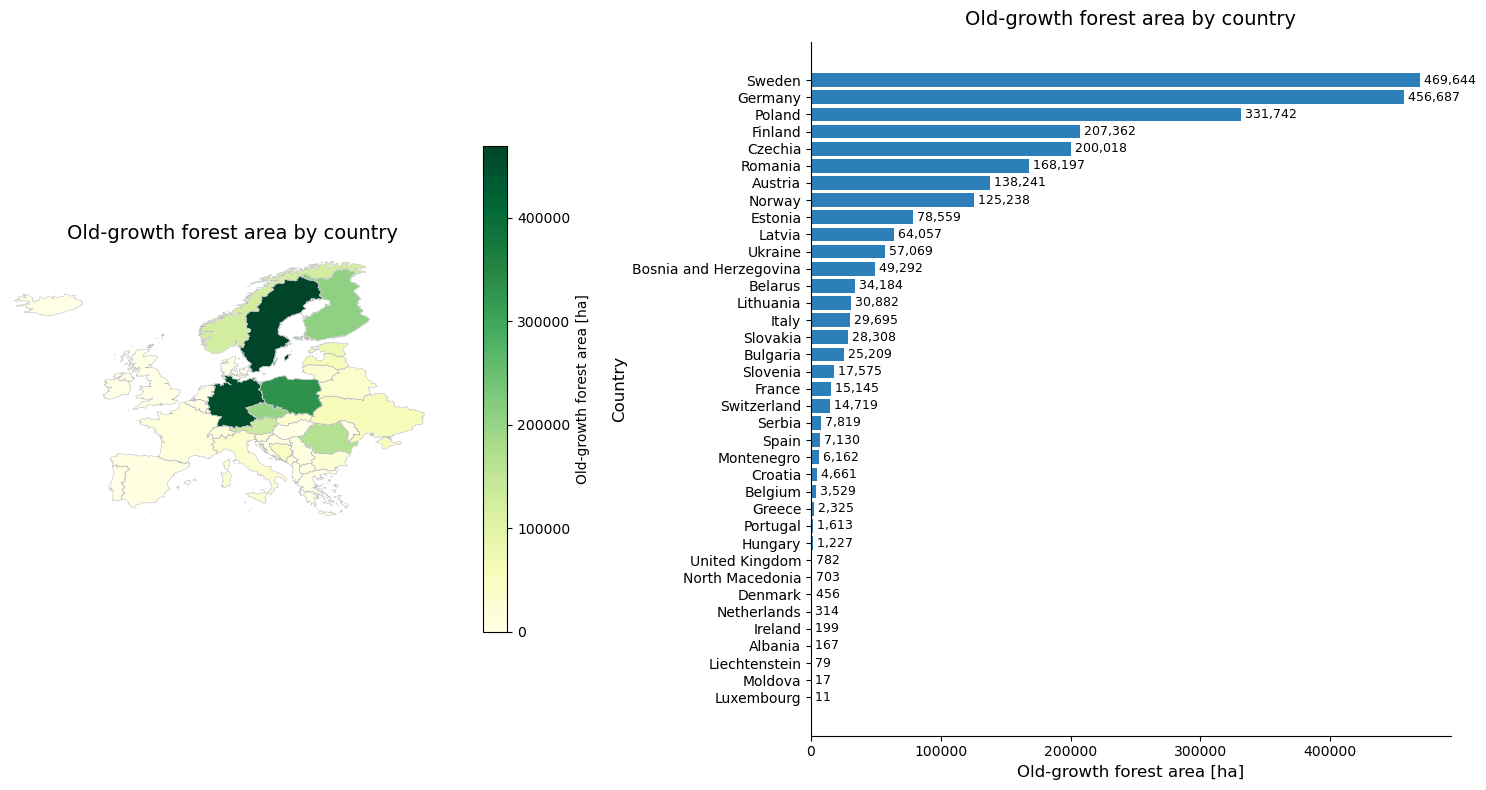

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_country_map_barplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_country_map_barplot.svg


In [57]:
# -------------------------------------------------
# COMBINED FIGURE: MAP + BARPLOT
# -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 8),
    gridspec_kw={"width_ratios": [1, 1.15]}
)

# -------------------------
# LEFT: MAP
# -------------------------
countries_map.plot(
    column="oldgrowth_area_ha",
    cmap="YlGn",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Old-growth forest area [ha]",
        "shrink": 0.7
    },
    ax=ax1
)

countries_map.boundary.plot(
    ax=ax1,
    color="0.7",
    linewidth=0.35
)

ax1.set_xlim(-25, 45)
ax1.set_ylim(34, 72)
ax1.set_title("Old-growth forest area by country", fontsize=14, pad=12)
ax1.set_axis_off()

# -------------------------
# RIGHT: BARPLOT
# -------------------------
ax2.barh(
    country_bar["country"],
    country_bar["oldgrowth_area_ha"],
    color="#2C7FB8"
)

ax2.set_xlabel("Old-growth forest area [ha]", fontsize=12)
ax2.set_ylabel("Country", fontsize=12)
ax2.set_title("Old-growth forest area by country", fontsize=14, pad=12)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="both", labelsize=10)

# Werte optional anschreiben
for i, value in enumerate(country_bar["oldgrowth_area_ha"]):
    ax2.text(
        value,
        i,
        f" {value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# -------------------------------------------------
# EXPORT
# -------------------------------------------------
out_png = os.path.join(out_dir, "old_growth_area_by_country_map_barplot.png")
out_svg = os.path.join(out_dir, "old_growth_area_by_country_map_barplot.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

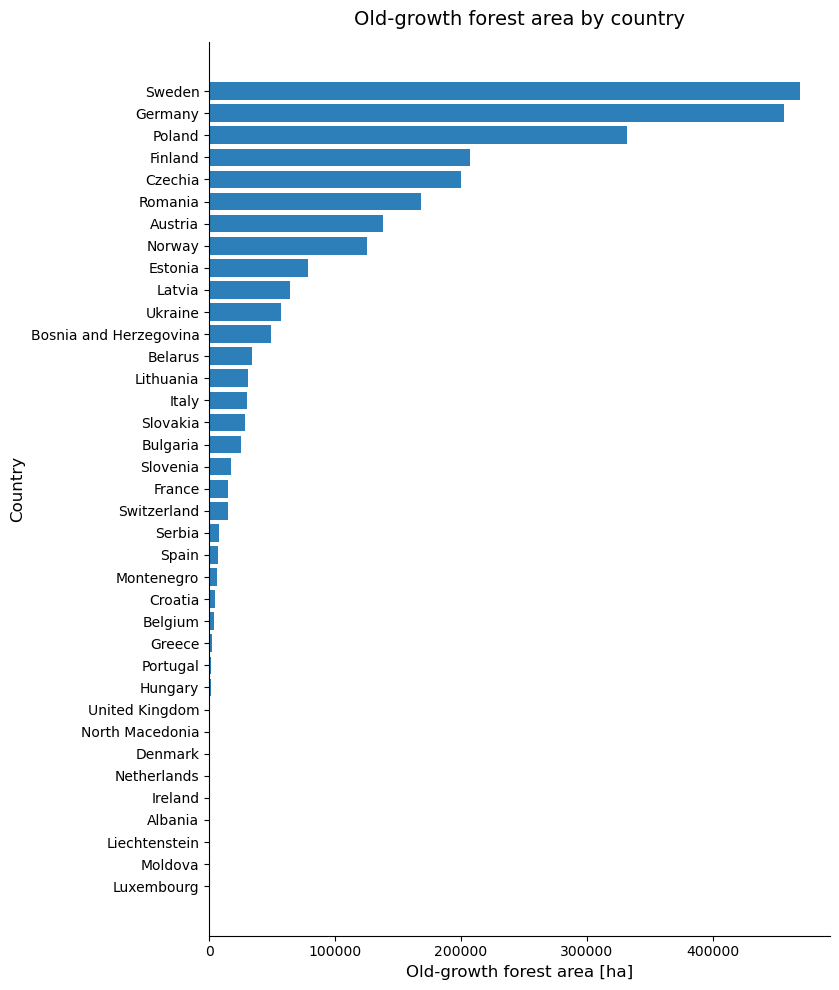

Saved barplot PNG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_country_barplot.png
Saved barplot SVG: /mnt/eo/EO4Backcasting/figures/old_growth_area_by_country_barplot.svg


In [58]:
fig, ax = plt.subplots(figsize=(8.5, 10))

ax.barh(
    country_bar["country"],
    country_bar["oldgrowth_area_ha"],
    color="#2C7FB8"
)

ax.set_xlabel("Old-growth forest area [ha]", fontsize=12)
ax.set_ylabel("Country", fontsize=12)
ax.set_title("Old-growth forest area by country", fontsize=14, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

out_png_bar = os.path.join(out_dir, "old_growth_area_by_country_barplot.png")
out_svg_bar = os.path.join(out_dir, "old_growth_area_by_country_barplot.svg")

fig.savefig(out_png_bar, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_bar, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved barplot PNG:", out_png_bar)
print("Saved barplot SVG:", out_svg_bar)

In [59]:
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

In [62]:
forest_mask_fp = "/mnt/eo/EFDA_v211/forestlanduse_mask_EUmosaic3035.tif"

import os
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# -------------------------------------------------
# FILE PATHS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
forest_mask_fp = "/mnt/eo/EFDA_v211/forestlanduse_mask_EUmosaic3035.tif"  # <-- anpassen
country_gpkg = "/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg"

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
country_name_col = "NAME_ENGL"
pixel_area_ha = 0.09  # 30 m Pixel
forest_value = 1      # falls deine Waldmaske anders codiert ist, hier ändern

exclude_russia = True

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom",
    "Vatican"
]


In [63]:
# -------------------------------------------------
# LOAD COUNTRY VECTOR
# -------------------------------------------------
countries = gpd.read_file(country_gpkg)

with rasterio.open(old_growth_fp) as old_src:
    if countries.crs != old_src.crs:
        countries = countries.to_crs(old_src.crs)

countries = countries[~countries.geometry.is_empty & countries.geometry.notna()].copy()
countries["geometry"] = countries.geometry.make_valid()

countries = countries.reset_index(drop=True)
countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)

country_lookup = dict(zip(countries["country_code"], countries[country_name_col]))
sindex = countries.sindex

# -------------------------------------------------
# COUNT FOREST AND OLD-GROWTH PIXELS BY COUNTRY
# -------------------------------------------------
forest_counter = Counter()
oldgrowth_counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:

    with WarpedVRT(
        forest_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=forest_src.nodata,
        nodata=0
    ) as forest_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting forest and old-growth area by country"):

            old = old_src.read(1, window=window)
            forest = forest_vrt.read(1, window=window)

            # Nur Blöcke bearbeiten, wo überhaupt Wald oder Old-growth vorkommt
            if not (np.any(forest == forest_value) or np.any(old == 1)):
                continue

            b = window_bounds(window, old_src.transform)
            block_geom = box(*b)

            candidate_idx = list(sindex.intersection(block_geom.bounds))
            if len(candidate_idx) == 0:
                continue

            countries_block = countries.iloc[candidate_idx].copy()
            countries_block = countries_block[countries_block.intersects(block_geom)]

            if countries_block.empty:
                continue

            shapes = zip(countries_block.geometry, countries_block["country_code"])

            country_block = rasterize(
                shapes=shapes,
                out_shape=old.shape,
                transform=window_transform(window, old_src.transform),
                fill=0,
                dtype="int32",
                all_touched=False
            )

            valid_country = country_block != 0

            # Gesamtwaldfläche pro Land
            valid_forest = (
                valid_country &
                (forest == forest_value)
            )

            country_vals_forest = country_block[valid_forest].astype(np.int32)

            if country_vals_forest.size > 0:
                unique, counts = np.unique(country_vals_forest, return_counts=True)
                forest_counter.update(dict(zip(unique, counts)))

            # Old-growth-Fläche pro Land
            valid_oldgrowth = (
                valid_country &
                (old == 1)
            )

            country_vals_oldgrowth = country_block[valid_oldgrowth].astype(np.int32)

            if country_vals_oldgrowth.size > 0:
                unique, counts = np.unique(country_vals_oldgrowth, return_counts=True)
                oldgrowth_counter.update(dict(zip(unique, counts)))

Counting forest and old-growth area by country:   0%|          | 0/140000 [00:00<?, ?it/s]

In [64]:
# -------------------------------------------------
# BUILD COUNTRY SUMMARY TABLE
# -------------------------------------------------
df_forest = pd.DataFrame(
    forest_counter.items(),
    columns=["country_code", "forest_pixels"]
)

df_old = pd.DataFrame(
    oldgrowth_counter.items(),
    columns=["country_code", "oldgrowth_pixels"]
)

df_country_share = df_forest.merge(
    df_old,
    on="country_code",
    how="left"
)

df_country_share["oldgrowth_pixels"] = df_country_share["oldgrowth_pixels"].fillna(0)

df_country_share["country"] = df_country_share["country_code"].map(country_lookup)

df_country_share["forest_area_ha"] = df_country_share["forest_pixels"] * pixel_area_ha
df_country_share["oldgrowth_area_ha"] = df_country_share["oldgrowth_pixels"] * pixel_area_ha

df_country_share["oldgrowth_share_percent"] = (
    df_country_share["oldgrowth_area_ha"] /
    df_country_share["forest_area_ha"] *
    100
)

# Nur Europa und optional Russland ausschließen
df_country_share = df_country_share[
    df_country_share["country"].isin(european_countries)
].copy()

if exclude_russia:
    df_country_share = df_country_share[
        df_country_share["country"] != "Russian Federation"
    ].copy()

df_country_share = df_country_share.sort_values(
    "oldgrowth_share_percent",
    ascending=False
)

df_country_share.head(20)

,country_code,forest_pixels,oldgrowth_pixels,country,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent
17,60,36306141,2235684.0,Czechia,3267552.69,201211.56,6.157867
12,61,135784176,5085685.0,Germany,12220575.84,457711.65,3.745418
23,22,49986108,1551249.0,Austria,4498749.72,139612.41,3.103360
11,179,123880266,3714340.0,Poland,11149223.94,334290.60,2.998331
5,68,31179762,879112.0,Estonia,2806178.58,79120.08,2.819496
21,188,98257774,1905604.0,Romania,8843199.66,171504.36,1.939393
6,137,42973013,716000.0,Latvia,3867571.17,64440.00,1.666162
31,26,33448993,548860.0,Bosnia and Herzegovina,3010409.37,49397.40,1.640886
3,159,340033918,5307135.0,Sweden,30603052.62,477642.15,1.560766
27,203,14824841,196543.0,Slovenia,1334235.69,17688.87,1.325768


In [68]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import numpy as np

# -------------------------------------------------
# SHARED COLOR SCALE
# -------------------------------------------------
cmap = plt.get_cmap("YlGnBu")

vmin = 0
vmax = df_country_share["oldgrowth_share_percent"].max()

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Farbe pro Land basierend auf oldgrowth_share_percent
df_country_share["plot_color"] = df_country_share["oldgrowth_share_percent"].apply(
    lambda x: cmap(norm(x))
)

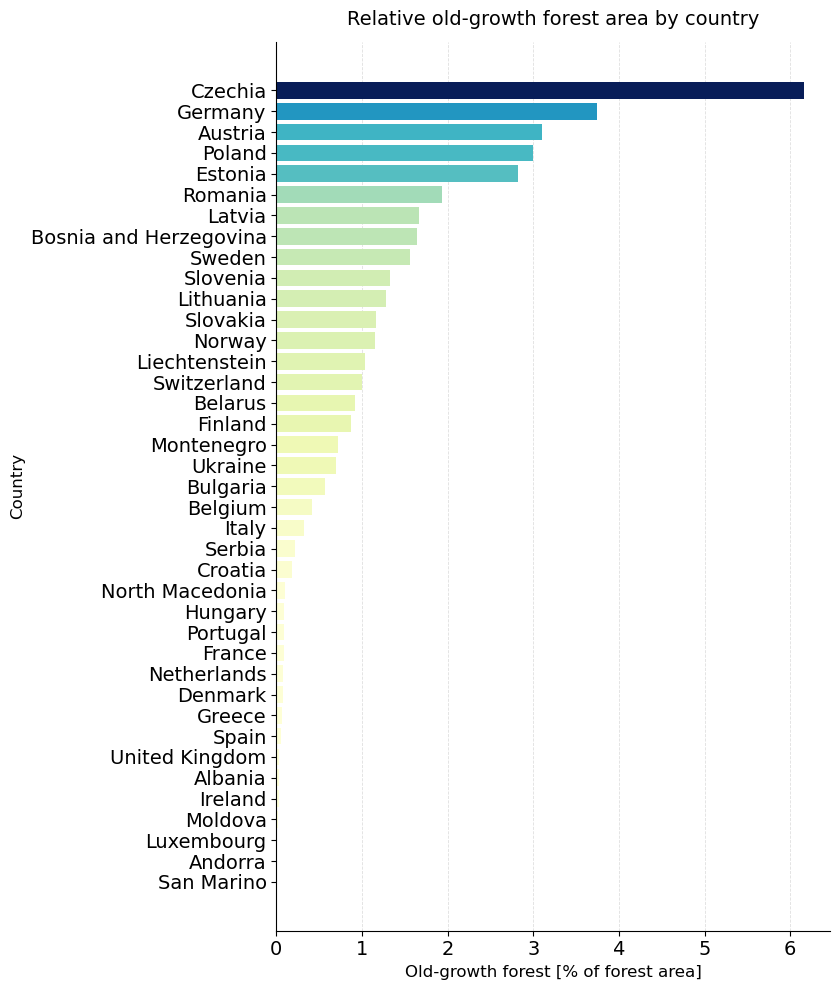

Saved barplot PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.png
Saved barplot SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.svg


In [71]:
# -------------------------------------------------
# BARPLOT: SAME COLORS AS MAP
# -------------------------------------------------
top_n_bar = None  # z.B. 25, falls du nur Top-25 zeigen willst

if top_n_bar is not None:
    country_bar = df_country_share.sort_values(
        "oldgrowth_share_percent",
        ascending=False
    ).head(top_n_bar).copy()
else:
    country_bar = df_country_share.copy()

country_bar = country_bar.sort_values("oldgrowth_share_percent", ascending=True)

# Farben aus derselben Skala
country_bar["plot_color"] = country_bar["oldgrowth_share_percent"].apply(
    lambda x: cmap(norm(x))
)

fig, ax = plt.subplots(figsize=(8.5, 10))

ax.barh(
    country_bar["country"],
    country_bar["oldgrowth_share_percent"],
    color=country_bar["plot_color"]
)

ax.set_xlabel("Old-growth forest [% of forest area]", fontsize=12)
ax.set_ylabel("Country", fontsize=12)
ax.set_title("Relative old-growth forest area by country", fontsize=14, pad=12)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()

out_png_bar = os.path.join(out_dir, "old_growth_share_of_forest_by_country_barplot_matched_colors.png")
out_svg_bar = os.path.join(out_dir, "old_growth_share_of_forest_by_country_barplot_matched_colors.svg")

fig.savefig(out_png_bar, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_bar, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved barplot PNG:", out_png_bar)
print("Saved barplot SVG:", out_svg_bar)

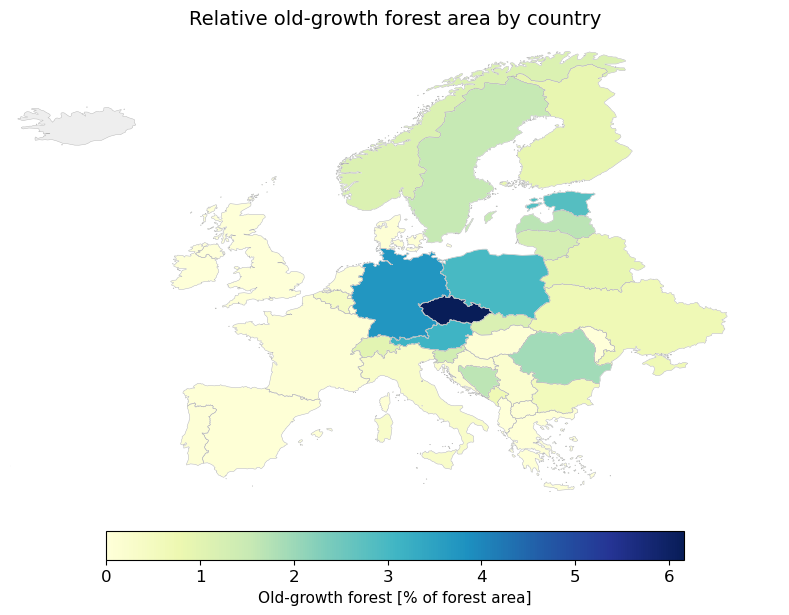

Saved map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.png
Saved map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.svg


In [72]:
# -------------------------------------------------
# MAP: OLD-GROWTH SHARE OF FOREST AREA
# -------------------------------------------------
countries_map = countries.copy()
countries_map["country"] = countries_map[country_name_col]

countries_map = countries_map[
    countries_map["country"].isin(european_countries)
].copy()

if exclude_russia:
    countries_map = countries_map[
        countries_map["country"] != "Russian Federation"
    ].copy()

countries_map = countries_map.merge(
    df_country_share[["country", "oldgrowth_share_percent", "plot_color"]],
    on="country",
    how="left"
)

countries_map["oldgrowth_share_percent"] = countries_map["oldgrowth_share_percent"].fillna(0)
countries_map["plot_color"] = countries_map["plot_color"].fillna("#eeeeee")

countries_map = countries_map.to_crs(4326)

fig, ax = plt.subplots(figsize=(8, 8))

countries_map.plot(
    color=countries_map["plot_color"],
    linewidth=0.5,
    edgecolor="white",
    ax=ax
)

countries_map.boundary.plot(
    ax=ax,
    color="0.7",
    linewidth=0.35
)

# eigene Colorbar mit gleicher Skala
# eigene Colorbar mit gleicher Skala, horizontal unter der Karte
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    shrink=0.75,
    fraction=0.045,
    pad=0.04
)

cbar.set_label("Old-growth forest [% of forest area]", fontsize=11)
cbar.ax.tick_params(labelsize=12)


ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

ax.set_title("Relative old-growth forest area by country", fontsize=14, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_map = os.path.join(out_dir, "old_growth_share_of_forest_by_country_map_matched_colors.png")
out_svg_map = os.path.join(out_dir, "old_growth_share_of_forest_by_country_map_matched_colors.svg")

fig.savefig(out_png_map, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_map, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved map PNG:", out_png_map)
print("Saved map SVG:", out_svg_map)

In [73]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box
from collections import Counter
from tqdm.auto import tqdm

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
forest_mask_fp = "/path/to/your/forest_mask.tif"   # <- anpassen

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

country_name_col = "NAME_ENGL"
exclude_russia = True
forest_value = 1
pixel_area_ha = 0.09   # 30 m pixel

# Hexagon-Größe:
# Das ist der Radius (Mittelpunkt -> Ecke) in Metern.
# 50_000 = eher fein, 75_000 = guter Europa-Kompromiss, 100_000 = gröber
hex_radius = 75000

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom",
    "Vatican"
]

In [74]:
# -------------------------------------------------
# HELPER: CREATE HEX GRID
# -------------------------------------------------
def create_hex_grid(bounds, hex_radius, crs):
    """
    Create a flat-top hexagon grid for given bounds.
    bounds: (minx, miny, maxx, maxy)
    hex_radius: distance from center to vertex in map units
    """
    minx, miny, maxx, maxy = bounds

    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius

    hexagons = []
    hex_ids = []

    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1

    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy

        while y < maxy + dy:
            cy = y + y_offset

            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [
                (x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a))
                for a in angles
            ]

            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1

            y += dy

        x += dx
        col += 1

    hexes = gpd.GeoDataFrame(
        {"hex_id": hex_ids},
        geometry=hexagons,
        crs=crs
    )

    return hexes

In [76]:
# -------------------------------------------------
# PREPARE EUROPE GEOMETRY
# -------------------------------------------------
with rasterio.open(old_growth_fp) as old_src:
    target_crs = old_src.crs

countries_eur = countries.copy()
countries_eur["country"] = countries_eur[country_name_col]

# Nur europäische Länder behalten
countries_eur = countries_eur[
    countries_eur["country"].isin(european_countries)
].copy()

# Russland optional ausschließen
if exclude_russia:
    countries_eur = countries_eur[
        countries_eur["country"] != "Russian Federation"
    ].copy()

# Auf Ziel-CRS des Old-growth-Rasters bringen
if countries_eur.crs != target_crs:
    countries_eur = countries_eur.to_crs(target_crs)

# Nur valide Geometrien behalten
countries_eur = countries_eur[
    countries_eur.geometry.notna() &
    ~countries_eur.geometry.is_empty
].copy()

# Geometrien reparieren, falls nötig
countries_eur["geometry"] = countries_eur.geometry.make_valid()

# Europa-Gesamtgeometrie für das Zuschneiden des Hexagonrasters
# ersetzt die veraltete unary_union-Variante
europe_geom = countries_eur.geometry.union_all()

# Bounding Box für Hexagonraster
europe_bounds = countries_eur.total_bounds

print("Number of European countries:", len(countries_eur))
print("Europe bounds:", europe_bounds)

Number of European countries: 41
Europe bounds: [-2824090.7973 -3075174.2438 10025281.546   5411096.2608]


In [77]:
# -------------------------------------------------
# CREATE HEX GRID OVER EUROPE
# -------------------------------------------------
hexes = create_hex_grid(
    bounds=europe_bounds,
    hex_radius=hex_radius,
    crs=countries_eur.crs
)

# nur Hexagone behalten, die Europa schneiden
hexes = hexes[hexes.intersects(europe_geom)].copy()
hexes = hexes.reset_index(drop=True)

# neue fortlaufende IDs
hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype(np.int32)

print("Number of hexagons:", len(hexes))

Number of hexagons: 639


In [79]:
# -------------------------------------------------
# COUNT FOREST + OLD-GROWTH PIXELS PER HEXAGON
# -------------------------------------------------
forest_mask_fp = "/mnt/eo/EFDA_v211/forest_landuse_aligned.tif"

hex_sindex = hexes.sindex

forest_counter = Counter()
oldgrowth_counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:

    with WarpedVRT(
        forest_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=forest_src.nodata,
        nodata=0
    ) as forest_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting forest and old-growth by hexagon"):

            old = old_src.read(1, window=window)
            forest = forest_vrt.read(1, window=window)

            # Nur Blöcke mit Wald oder Old-growth überhaupt anschauen
            if not (np.any(forest == forest_value) or np.any(old == 1)):
                continue

            # Geometrie des Blocks
            b = window_bounds(window, old_src.transform)
            block_geom = box(*b)

            # nur relevante Hexagone auswählen
            candidate_idx = list(hex_sindex.intersection(block_geom.bounds))
            if len(candidate_idx) == 0:
                continue

            hex_block = hexes.iloc[candidate_idx].copy()
            hex_block = hex_block[hex_block.intersects(block_geom)]

            if hex_block.empty:
                continue

            # Hexagone für diesen Block rasterisieren
            shapes = zip(hex_block.geometry, hex_block["hex_id"])

            hex_raster = rasterize(
                shapes=shapes,
                out_shape=old.shape,
                transform=window_transform(window, old_src.transform),
                fill=0,
                dtype="int32",
                all_touched=False
            )

            valid_hex = hex_raster != 0

            # forest pixels per hex
            valid_forest = valid_hex & (forest == forest_value)
            forest_ids = hex_raster[valid_forest].astype(np.int32)

            if forest_ids.size > 0:
                unique, counts = np.unique(forest_ids, return_counts=True)
                forest_counter.update(dict(zip(unique, counts)))

            # old-growth pixels per hex
            valid_old = valid_forest & (old == 1)
            old_ids = hex_raster[valid_old].astype(np.int32)

            if old_ids.size > 0:
                unique, counts = np.unique(old_ids, return_counts=True)
                oldgrowth_counter.update(dict(zip(unique, counts)))

Counting forest and old-growth by hexagon:   0%|          | 0/140000 [00:00<?, ?it/s]

In [80]:
# -------------------------------------------------
# BUILD HEX SUMMARY TABLE
# -------------------------------------------------
df_forest_hex = pd.DataFrame(
    forest_counter.items(),
    columns=["hex_id", "forest_pixels"]
)

df_old_hex = pd.DataFrame(
    oldgrowth_counter.items(),
    columns=["hex_id", "oldgrowth_pixels"]
)

df_hex = df_forest_hex.merge(
    df_old_hex,
    on="hex_id",
    how="left"
)

df_hex["oldgrowth_pixels"] = df_hex["oldgrowth_pixels"].fillna(0)

df_hex["forest_area_ha"] = df_hex["forest_pixels"] * pixel_area_ha
df_hex["oldgrowth_area_ha"] = df_hex["oldgrowth_pixels"] * pixel_area_ha

df_hex["oldgrowth_share_percent"] = (
    df_hex["oldgrowth_area_ha"] /
    df_hex["forest_area_ha"] * 100
)

hexes_plot = hexes.merge(df_hex, on="hex_id", how="left")

# Hexagone ohne Wald raus
hexes_plot = hexes_plot[hexes_plot["forest_area_ha"].notna()].copy()
hexes_plot = hexes_plot[hexes_plot["forest_area_ha"] > 0].copy()

print(hexes_plot.head())
print("Hexagons with forest:", len(hexes_plot))

    hex_id                                           geometry  forest_pixels  \
37      38  POLYGON ((2725909.203 1731266.747, 2688409.203...       901256.0   
38      39  POLYGON ((2725909.203 1861170.558, 2688409.203...      1790691.0   
39      40  POLYGON ((2725909.203 1991074.368, 2688409.203...      1260694.0   
40      41  POLYGON ((2838409.203 1796218.652, 2800909.203...      2005442.0   
41      42  POLYGON ((2838409.203 1926122.463, 2800909.203...      2965078.0   

    oldgrowth_pixels  forest_area_ha  oldgrowth_area_ha  \
37            1567.0        81113.04             141.03   
38             185.0       161162.19              16.65   
39            1750.0       113462.46             157.50   
40             650.0       180489.78              58.50   
41            5497.0       266857.02             494.73   

    oldgrowth_share_percent  
37                 0.173868  
38                 0.010331  
39                 0.138812  
40                 0.032412  
41            

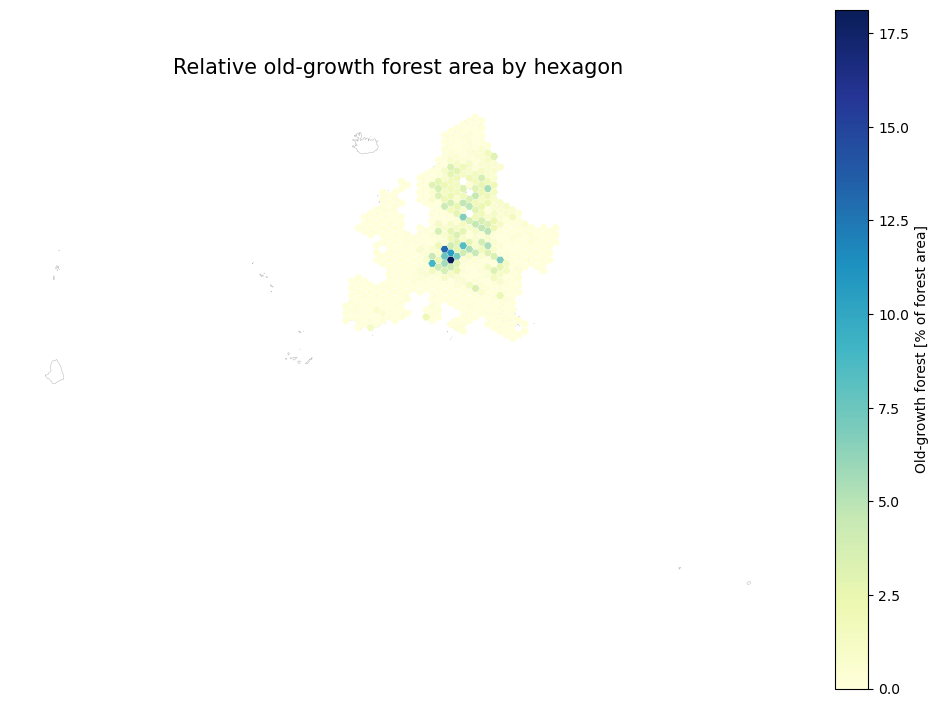

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_by_hexagon_map.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_by_hexagon_map.svg


In [81]:
# -------------------------------------------------
# PLOT HEXAGON MAP
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Hintergrund: Ländergrenzen
countries_eur.boundary.plot(
    ax=ax,
    color="0.75",
    linewidth=0.4,
    zorder=1
)

# Hexagonfläche
hexes_plot.plot(
    column="oldgrowth_share_percent",
    cmap="YlGnBu",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Old-growth forest [% of forest area]",
        "shrink": 0.7
    },
    ax=ax,
    zorder=2
)

ax.set_title("Relative old-growth forest area by hexagon", fontsize=15, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_share_by_hexagon_map.png")
out_svg = os.path.join(out_dir, "old_growth_share_by_hexagon_map.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [83]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# -------------------------------------------------
# FILTER OUT OVERSEAS TERRITORIES + ICELAND
# plotting-only, no resampling/counting needed
# -------------------------------------------------

# Mainland Europe bbox in lon/lat
# keeps Ireland/Portugal, removes Iceland and overseas territories
mainland_bbox_4326 = box(-12, 34, 35, 72)

# Countries for plotting
countries_eur_plot = countries_eur.copy()

# remove Iceland by attribute
if "country" in countries_eur_plot.columns:
    countries_eur_plot = countries_eur_plot[
        countries_eur_plot["country"] != "Iceland"
    ].copy()

# clip countries to mainland Europe bbox
countries_eur_plot_4326 = countries_eur_plot.to_crs(4326)
countries_eur_plot_4326 = gpd.clip(
    countries_eur_plot_4326,
    gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)
)

# back to original CRS for plotting with hexagons
countries_eur_plot = countries_eur_plot_4326.to_crs(countries_eur.crs)

# Hexagons for plotting
hexes_plot_tmp = hexes_plot.copy()

# use representative points to decide whether a hexagon belongs to mainland Europe
hex_points_4326 = hexes_plot_tmp.representative_point().to_crs(4326)

keep_hex = (
    (hex_points_4326.x >= -12) &
    (hex_points_4326.x <= 35) &
    (hex_points_4326.y >= 34) &
    (hex_points_4326.y <= 72)
)

hexes_plot_europe = hexes_plot_tmp.loc[keep_hex].copy()

print("Hexagons before filtering:", len(hexes_plot))
print("Hexagons after filtering:", len(hexes_plot_europe))

Hexagons before filtering: 568
Hexagons after filtering: 550


Number of European countries: 40
Europe bounds: [-2824090.7973 -3075174.2438 10025281.546   5411096.2608]
Number of clipped hexagons: 2403


Counting forest and old-growth by clipped hexagon:   0%|          | 0/140000 [00:00<?, ?it/s]

Hexagons with sufficient forest: 2123
    hex_id  forest_area_ha  oldgrowth_area_ha  oldgrowth_share_percent
7        8         1819.53               0.00                 0.000000
8        9         2025.45               0.00                 0.000000
9       10        38186.37              28.98                 0.075891
11      12         5954.31               0.00                 0.000000
13      14        12901.32               0.00                 0.000000


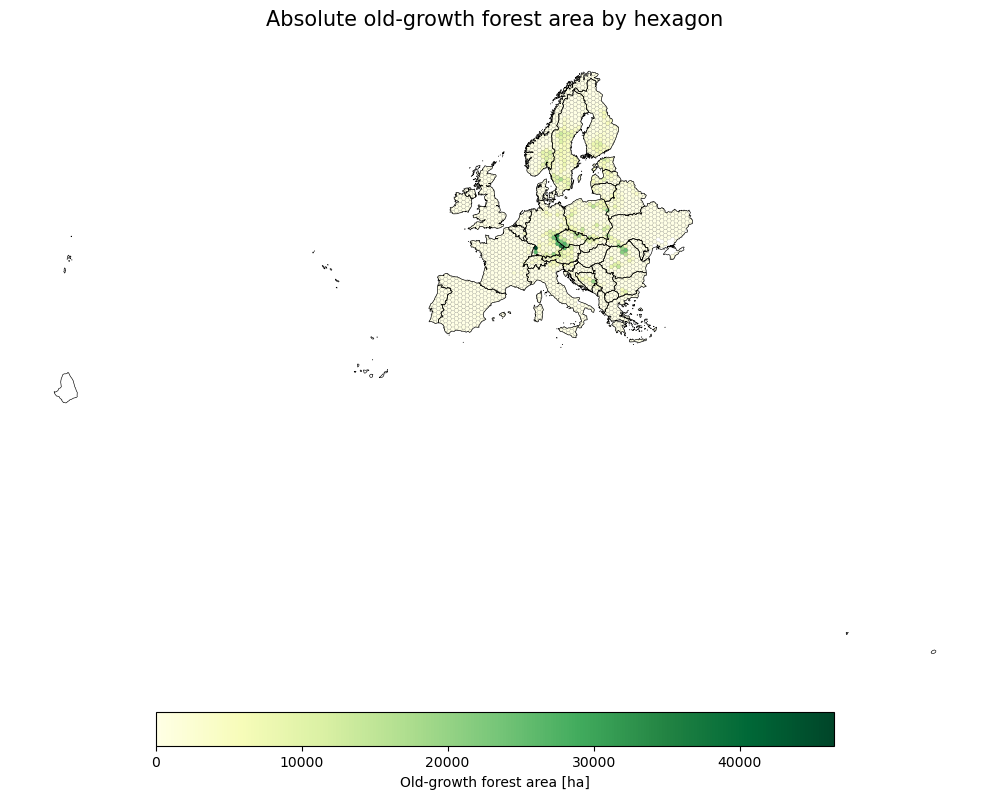

Saved absolute hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_clipped_hexagon_map.png
Saved absolute hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_clipped_hexagon_map.svg


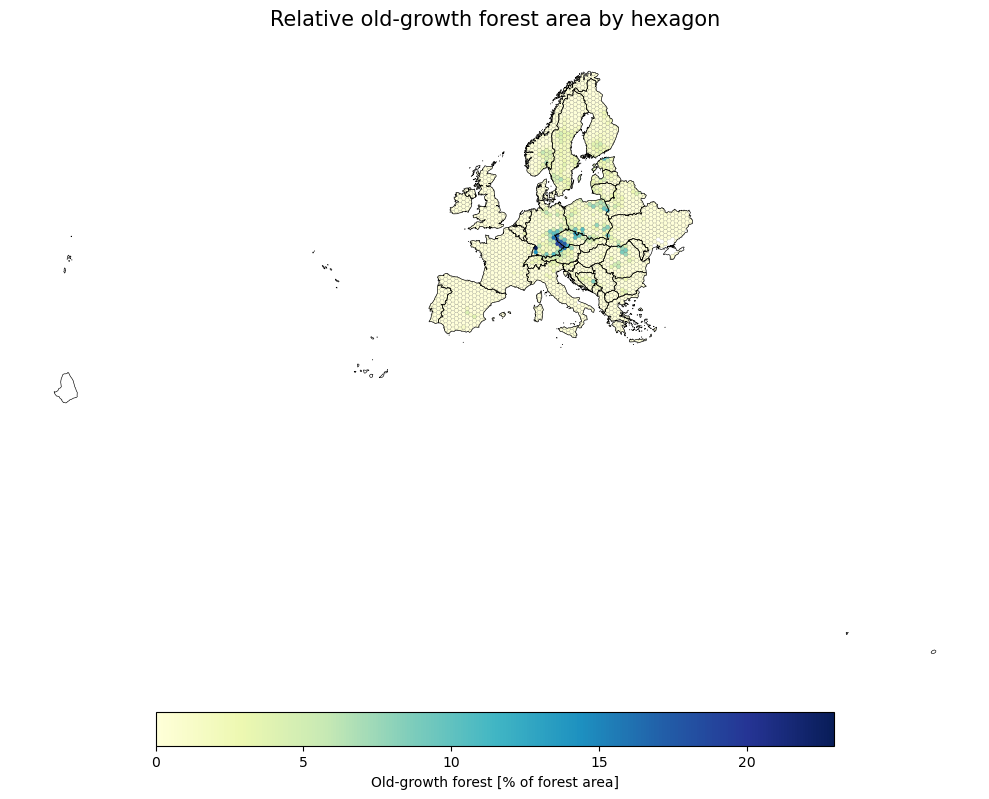

Saved relative hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_clipped_hexagon_map.png
Saved relative hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_clipped_hexagon_map.svg


In [86]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box
from collections import Counter
from tqdm.auto import tqdm

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
forest_mask_fp = "/mnt/eo/EFDA_v211/forest_landuse_aligned.tif"

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

country_name_col = "NAME_ENGL"
exclude_russia = True

# Falls deine Waldmaske Wald anders codiert, hier ändern
forest_value = 1

# 30 m Pixel: 900 m² = 0.09 ha
pixel_area_ha = 0.09

# Kleinere Hexagone
# 75_000 war zu grob; 35_000 ist deutlich feiner
hex_radius = 35_000

# Mindestwaldfläche pro Hexagon
min_forest_area_ha = 1_000

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom",
    "Vatican"
]

# -------------------------------------------------
# HELPER: CREATE HEX GRID
# -------------------------------------------------
def create_hex_grid(bounds, hex_radius, crs):
    minx, miny, maxx, maxy = bounds

    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius

    hexagons = []
    hex_ids = []

    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1

    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy

        while y < maxy + dy:
            cy = y + y_offset

            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [
                (x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a))
                for a in angles
            ]

            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1

            y += dy

        x += dx
        col += 1

    return gpd.GeoDataFrame(
        {"hex_id": hex_ids},
        geometry=hexagons,
        crs=crs
    )

# -------------------------------------------------
# PREPARE EUROPE GEOMETRY
# -------------------------------------------------
with rasterio.open(old_growth_fp) as old_src:
    target_crs = old_src.crs

countries_eur = countries.copy()
countries_eur["country"] = countries_eur[country_name_col]

# Nur Europa, ohne Überseegebiete und ohne Island
countries_eur = countries_eur[
    countries_eur["country"].isin(european_countries)
].copy()

if exclude_russia:
    countries_eur = countries_eur[
        countries_eur["country"] != "Russian Federation"
    ].copy()

if countries_eur.crs != target_crs:
    countries_eur = countries_eur.to_crs(target_crs)

countries_eur = countries_eur[
    countries_eur.geometry.notna() &
    ~countries_eur.geometry.is_empty
].copy()

countries_eur["geometry"] = countries_eur.geometry.make_valid()

europe_geom = countries_eur.geometry.union_all()
europe_bounds = countries_eur.total_bounds

print("Number of European countries:", len(countries_eur))
print("Europe bounds:", europe_bounds)

# -------------------------------------------------
# CREATE SMALLER HEX GRID AND CLIP TO COUNTRY LAYER
# -------------------------------------------------
hexes = create_hex_grid(
    bounds=europe_bounds,
    hex_radius=hex_radius,
    crs=countries_eur.crs
)

# Nur Hexagone behalten, die Europa schneiden
hexes = hexes[hexes.intersects(europe_geom)].copy()

# Hexagone an Ländergrenzen croppen
europe_clip = gpd.GeoDataFrame(
    geometry=[europe_geom],
    crs=countries_eur.crs
)

hexes = gpd.clip(hexes, europe_clip)

hexes = hexes[
    hexes.geometry.notna() &
    ~hexes.geometry.is_empty
].copy()

hexes["geometry"] = hexes.geometry.make_valid()

# Neue IDs nach dem Clippen
hexes = hexes.reset_index(drop=True)
hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype(np.int32)

print("Number of clipped hexagons:", len(hexes))

# -------------------------------------------------
# COUNT FOREST AND OLD-GROWTH PIXELS PER CLIPPED HEXAGON
# -------------------------------------------------
hex_sindex = hexes.sindex

forest_counter = Counter()
oldgrowth_counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:

    with WarpedVRT(
        forest_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=forest_src.nodata,
        nodata=0
    ) as forest_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting forest and old-growth by clipped hexagon"):

            old = old_src.read(1, window=window)
            forest = forest_vrt.read(1, window=window)

            if not (np.any(forest == forest_value) or np.any(old == 1)):
                continue

            b = window_bounds(window, old_src.transform)
            block_geom = box(*b)

            candidate_idx = list(hex_sindex.intersection(block_geom.bounds))
            if len(candidate_idx) == 0:
                continue

            hex_block = hexes.iloc[candidate_idx].copy()
            hex_block = hex_block[hex_block.intersects(block_geom)]

            if hex_block.empty:
                continue

            shapes = zip(hex_block.geometry, hex_block["hex_id"])

            hex_raster = rasterize(
                shapes=shapes,
                out_shape=old.shape,
                transform=window_transform(window, old_src.transform),
                fill=0,
                dtype="int32",
                all_touched=False
            )

            valid_hex = hex_raster != 0

            # Gesamtwaldfläche pro Hexagon
            valid_forest = valid_hex & (forest == forest_value)
            forest_ids = hex_raster[valid_forest].astype(np.int32)

            if forest_ids.size > 0:
                unique, counts = np.unique(forest_ids, return_counts=True)
                forest_counter.update(dict(zip(unique, counts)))

            # Old-growth-Fläche pro Hexagon
            # Hier wird Old-growth zusätzlich auf Waldmaske begrenzt.
            valid_oldgrowth = valid_hex & (forest == forest_value) & (old == 1)
            old_ids = hex_raster[valid_oldgrowth].astype(np.int32)

            if old_ids.size > 0:
                unique, counts = np.unique(old_ids, return_counts=True)
                oldgrowth_counter.update(dict(zip(unique, counts)))

# -------------------------------------------------
# BUILD HEX SUMMARY TABLE
# -------------------------------------------------
df_forest_hex = pd.DataFrame(
    forest_counter.items(),
    columns=["hex_id", "forest_pixels"]
)

df_old_hex = pd.DataFrame(
    oldgrowth_counter.items(),
    columns=["hex_id", "oldgrowth_pixels"]
)

df_hex = df_forest_hex.merge(
    df_old_hex,
    on="hex_id",
    how="left"
)

df_hex["oldgrowth_pixels"] = df_hex["oldgrowth_pixels"].fillna(0)

df_hex["forest_area_ha"] = df_hex["forest_pixels"] * pixel_area_ha
df_hex["oldgrowth_area_ha"] = df_hex["oldgrowth_pixels"] * pixel_area_ha

df_hex["oldgrowth_share_percent"] = (
    df_hex["oldgrowth_area_ha"] /
    df_hex["forest_area_ha"] *
    100
)

hexes_plot = hexes.merge(df_hex, on="hex_id", how="left")

# Nur Hexagone mit ausreichend Wald behalten
hexes_plot = hexes_plot[
    hexes_plot["forest_area_ha"].notna() &
    (hexes_plot["forest_area_ha"] >= min_forest_area_ha)
].copy()

print("Hexagons with sufficient forest:", len(hexes_plot))
print(hexes_plot[["hex_id", "forest_area_ha", "oldgrowth_area_ha", "oldgrowth_share_percent"]].head())

# -------------------------------------------------
# PLOT 1: ABSOLUTE OLD-GROWTH AREA PER CLIPPED HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_plot.plot(
    column="oldgrowth_area_ha",
    cmap="YlGn",
    linewidth=0.10,
    edgecolor="0.25",
    legend=True,
    legend_kwds={
        "label": "Old-growth forest area [ha]",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.03
    },
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.45,
    zorder=3
)

ax.set_title("Absolute old-growth forest area by hexagon", fontsize=15, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_abs = os.path.join(out_dir, "old_growth_absolute_area_by_clipped_hexagon_map.png")
out_svg_abs = os.path.join(out_dir, "old_growth_absolute_area_by_clipped_hexagon_map.svg")

fig.savefig(out_png_abs, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_abs, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved absolute hex map PNG:", out_png_abs)
print("Saved absolute hex map SVG:", out_svg_abs)

# -------------------------------------------------
# PLOT 2: RELATIVE OLD-GROWTH SHARE PER CLIPPED HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_plot.plot(
    column="oldgrowth_share_percent",
    cmap="YlGnBu",
    linewidth=0.10,
    edgecolor="0.25",
    legend=True,
    legend_kwds={
        "label": "Old-growth forest [% of forest area]",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.03
    },
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.45,
    zorder=3
)

ax.set_title("Relative old-growth forest area by hexagon", fontsize=15, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_rel = os.path.join(out_dir, "old_growth_relative_share_by_clipped_hexagon_map.png")
out_svg_rel = os.path.join(out_dir, "old_growth_relative_share_by_clipped_hexagon_map.svg")

fig.savefig(out_png_rel, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_rel, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved relative hex map PNG:", out_png_rel)
print("Saved relative hex map SVG:", out_svg_rel)

Number of European country geometry parts: 661
Europe bounds: [2637951.1408115  1385081.87909904 6259528.10360713 5411096.26070502]
Number of clipped hexagons: 8219


Counting forest and old-growth by clipped hexagon:   0%|          | 0/140000 [00:00<?, ?it/s]

Hexagons with sufficient forest: 7553
   hex_id  forest_area_ha  oldgrowth_area_ha  oldgrowth_share_percent
3       4         3075.21               6.21                 0.201937
6       7         4745.88              11.79                 0.248426
7       8         3308.22               0.00                 0.000000
8       9         5771.16               0.00                 0.000000
9      10        13064.67               0.00                 0.000000
Absolute color vmax 98th percentile: 3424.9175999999998
Relative color vmax 98th percentile: 7.814869366641002


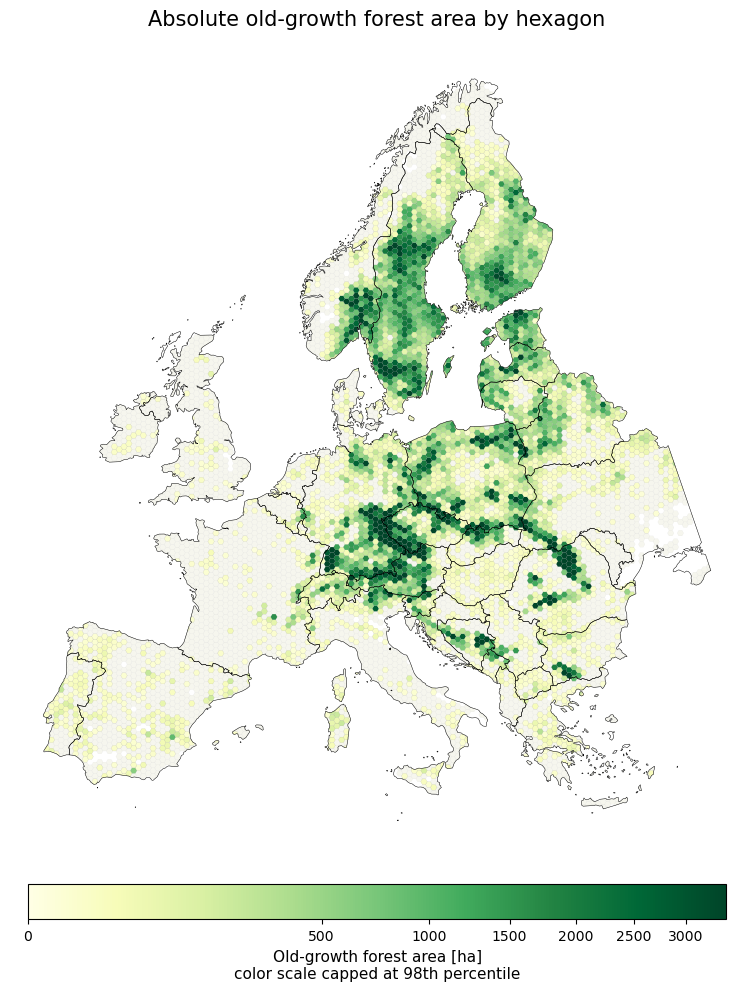

Saved absolute hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.png
Saved absolute hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.svg


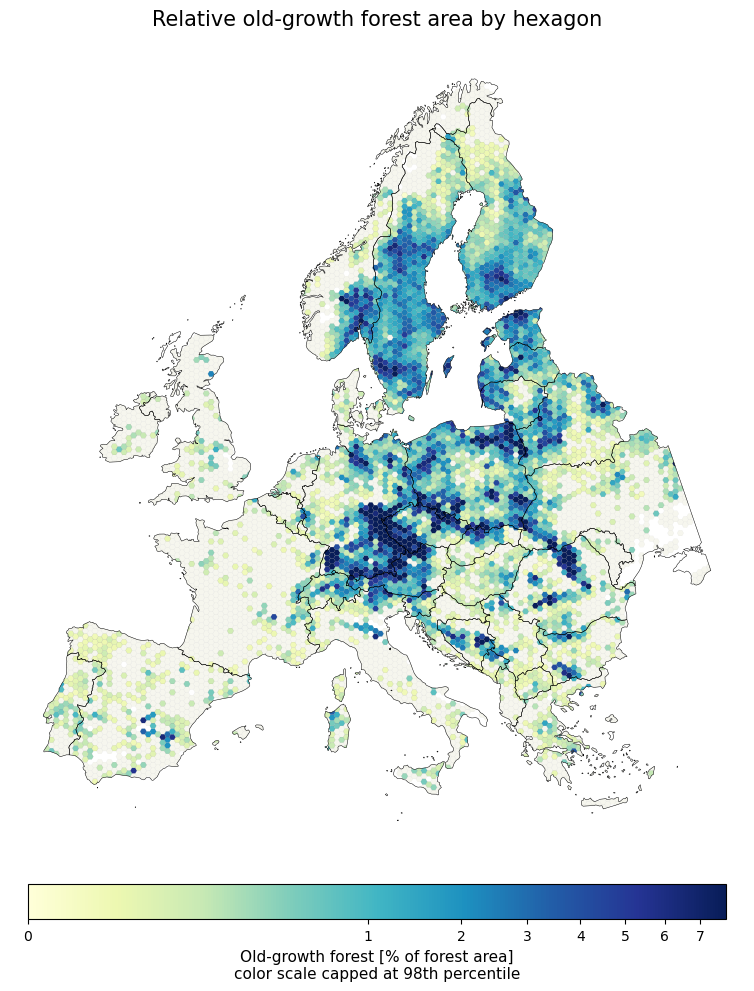

Saved relative hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.png
Saved relative hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.svg


In [88]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Polygon, box
from collections import Counter
from tqdm.auto import tqdm

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
old_growth_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
forest_mask_fp = "/mnt/eo/EFDA_v211/forest_landuse_aligned.tif"

out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

country_name_col = "NAME_ENGL"
exclude_russia = True

# Waldmaske: falls Wald anders codiert ist, hier ändern
forest_value = 1

# 30 m Pixel: 900 m² = 0.09 ha
pixel_area_ha = 0.09

# Kleinere Hexagone: Hälfte von 35 km
# Achtung: deutlich mehr Hexagone, Counting dauert länger
hex_radius = 17_500

# Kleine Randhexagone mit wenig Wald ausschließen
min_forest_area_ha = 500

# Europa-Liste ohne Iceland, ohne Russland, ohne Überseegebiete
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom", "Vatican"
]

# Mainland-Europe Bounding Box in lon/lat
# entfernt Überseegebiete und vermeidet sehr weit entfernte Geometrien
mainland_bbox_4326 = box(-11, 34, 35, 72)

# -------------------------------------------------
# HELPER: CREATE HEX GRID
# -------------------------------------------------
def create_hex_grid(bounds, hex_radius, crs):
    minx, miny, maxx, maxy = bounds

    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius

    hexagons = []
    hex_ids = []

    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1

    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy

        while y < maxy + dy:
            cy = y + y_offset

            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [
                (x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a))
                for a in angles
            ]

            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1

            y += dy

        x += dx
        col += 1

    return gpd.GeoDataFrame(
        {"hex_id": hex_ids},
        geometry=hexagons,
        crs=crs
    )

# -------------------------------------------------
# PREPARE EUROPE COUNTRY GEOMETRY
# -------------------------------------------------
with rasterio.open(old_growth_fp) as old_src:
    target_crs = old_src.crs

countries_eur = countries.copy()
countries_eur["country"] = countries_eur[country_name_col]

# nur europäische Länder
countries_eur = countries_eur[
    countries_eur["country"].isin(european_countries)
].copy()

# Russland optional ausschließen
if exclude_russia:
    countries_eur = countries_eur[
        countries_eur["country"] != "Russian Federation"
    ].copy()

# nach WGS84, Multipart-Geometrien trennen, Überseegebiete über bbox entfernen
countries_eur = countries_eur.to_crs(4326)
countries_eur = countries_eur.explode(index_parts=False).reset_index(drop=True)

bbox_gdf = gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)

# nur Geometrieteile behalten, deren representative point in Mainland-Europe bbox liegt
rep = countries_eur.representative_point()

keep_country_part = (
    (rep.x >= -11) &
    (rep.x <= 35) &
    (rep.y >= 34) &
    (rep.y <= 72)
)

countries_eur = countries_eur.loc[keep_country_part].copy()

# zusätzlich an bbox clippen
countries_eur = gpd.clip(countries_eur, bbox_gdf)

# zurück ins Raster-CRS
countries_eur = countries_eur.to_crs(target_crs)

countries_eur = countries_eur[
    countries_eur.geometry.notna() &
    ~countries_eur.geometry.is_empty
].copy()

countries_eur["geometry"] = countries_eur.geometry.make_valid()

europe_geom = countries_eur.geometry.union_all()
europe_bounds = countries_eur.total_bounds

print("Number of European country geometry parts:", len(countries_eur))
print("Europe bounds:", europe_bounds)

# -------------------------------------------------
# CREATE SMALL HEX GRID AND CLIP TO EUROPE
# -------------------------------------------------
hexes = create_hex_grid(
    bounds=europe_bounds,
    hex_radius=hex_radius,
    crs=countries_eur.crs
)

# nur Hexagone, die Europa schneiden
hexes = hexes[hexes.intersects(europe_geom)].copy()

# Hexagone an Ländergrenzen croppen
europe_clip = gpd.GeoDataFrame(
    geometry=[europe_geom],
    crs=countries_eur.crs
)

hexes = gpd.clip(hexes, europe_clip)

hexes = hexes[
    hexes.geometry.notna() &
    ~hexes.geometry.is_empty
].copy()

hexes["geometry"] = hexes.geometry.make_valid()

hexes = hexes.reset_index(drop=True)
hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype(np.int32)

print("Number of clipped hexagons:", len(hexes))

# -------------------------------------------------
# COUNT FOREST AND OLD-GROWTH PIXELS PER HEXAGON
# -------------------------------------------------
hex_sindex = hexes.sindex

forest_counter = Counter()
oldgrowth_counter = Counter()

with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:

    with WarpedVRT(
        forest_src,
        crs=old_src.crs,
        transform=old_src.transform,
        width=old_src.width,
        height=old_src.height,
        resampling=Resampling.nearest,
        src_nodata=forest_src.nodata,
        nodata=0
    ) as forest_vrt:

        windows = [window for _, window in old_src.block_windows(1)]

        for window in tqdm(windows, desc="Counting forest and old-growth by clipped hexagon"):

            old = old_src.read(1, window=window)
            forest = forest_vrt.read(1, window=window)

            if not (np.any(forest == forest_value) or np.any(old == 1)):
                continue

            b = window_bounds(window, old_src.transform)
            block_geom = box(*b)

            candidate_idx = list(hex_sindex.intersection(block_geom.bounds))
            if len(candidate_idx) == 0:
                continue

            hex_block = hexes.iloc[candidate_idx].copy()
            hex_block = hex_block[hex_block.intersects(block_geom)]

            if hex_block.empty:
                continue

            shapes = zip(hex_block.geometry, hex_block["hex_id"])

            hex_raster = rasterize(
                shapes=shapes,
                out_shape=old.shape,
                transform=window_transform(window, old_src.transform),
                fill=0,
                dtype="int32",
                all_touched=False
            )

            valid_hex = hex_raster != 0

            # Gesamtwaldfläche pro Hexagon
            valid_forest = valid_hex & (forest == forest_value)
            forest_ids = hex_raster[valid_forest].astype(np.int32)

            if forest_ids.size > 0:
                unique, counts = np.unique(forest_ids, return_counts=True)
                forest_counter.update(dict(zip(unique, counts)))

            # Old-growth-Fläche pro Hexagon, begrenzt auf Waldmaske
            valid_oldgrowth = valid_hex & (forest == forest_value) & (old == 1)
            old_ids = hex_raster[valid_oldgrowth].astype(np.int32)

            if old_ids.size > 0:
                unique, counts = np.unique(old_ids, return_counts=True)
                oldgrowth_counter.update(dict(zip(unique, counts)))

# -------------------------------------------------
# BUILD HEX SUMMARY TABLE
# -------------------------------------------------
df_forest_hex = pd.DataFrame(
    forest_counter.items(),
    columns=["hex_id", "forest_pixels"]
)

df_old_hex = pd.DataFrame(
    oldgrowth_counter.items(),
    columns=["hex_id", "oldgrowth_pixels"]
)

df_hex = df_forest_hex.merge(
    df_old_hex,
    on="hex_id",
    how="left"
)

df_hex["oldgrowth_pixels"] = df_hex["oldgrowth_pixels"].fillna(0)

df_hex["forest_area_ha"] = df_hex["forest_pixels"] * pixel_area_ha
df_hex["oldgrowth_area_ha"] = df_hex["oldgrowth_pixels"] * pixel_area_ha

df_hex["oldgrowth_share_percent"] = (
    df_hex["oldgrowth_area_ha"] /
    df_hex["forest_area_ha"] *
    100
)

hexes_plot = hexes.merge(df_hex, on="hex_id", how="left")

# nur Hexagone mit ausreichend Wald behalten
hexes_plot = hexes_plot[
    hexes_plot["forest_area_ha"].notna() &
    (hexes_plot["forest_area_ha"] >= min_forest_area_ha)
].copy()

print("Hexagons with sufficient forest:", len(hexes_plot))
print(hexes_plot[["hex_id", "forest_area_ha", "oldgrowth_area_ha", "oldgrowth_share_percent"]].head())

# -------------------------------------------------
# COLOR NORMALIZATION
# -------------------------------------------------
# Absolute Fläche: perzentilbasiert, damit wenige Hotspots nicht alles dominieren
abs_vmin = 0
abs_vmax = np.nanpercentile(hexes_plot["oldgrowth_area_ha"], 98)
abs_norm = mpl.colors.PowerNorm(gamma=0.45, vmin=abs_vmin, vmax=abs_vmax)
abs_cmap = plt.get_cmap("YlGn")

# Relative Fläche: ebenfalls gestreckt
rel_vmin = 0
rel_vmax = np.nanpercentile(hexes_plot["oldgrowth_share_percent"], 98)
rel_norm = mpl.colors.PowerNorm(gamma=0.35, vmin=rel_vmin, vmax=rel_vmax)
rel_cmap = plt.get_cmap("YlGnBu")

# Für Darstellung Werte kappen, Daten bleiben unverändert
hexes_plot["oldgrowth_area_ha_plot"] = hexes_plot["oldgrowth_area_ha"].clip(upper=abs_vmax)
hexes_plot["oldgrowth_share_percent_plot"] = hexes_plot["oldgrowth_share_percent"].clip(upper=rel_vmax)

print("Absolute color vmax 98th percentile:", abs_vmax)
print("Relative color vmax 98th percentile:", rel_vmax)

# -------------------------------------------------
# PLOT 1: ABSOLUTE OLD-GROWTH AREA PER HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_abs = hexes_plot[
    (hexes_plot["oldgrowth_area_ha"].isna()) |
    (hexes_plot["oldgrowth_area_ha"] <= 0)
].copy()

hexes_pos_abs = hexes_plot[
    (hexes_plot["oldgrowth_area_ha"].notna()) &
    (hexes_plot["oldgrowth_area_ha"] > 0)
].copy()

if len(hexes_zero_abs) > 0:
    hexes_zero_abs.plot(
        color="#f6f6ee",
        linewidth=0.05,
        edgecolor="0.75",
        ax=ax,
        zorder=1
    )

hexes_pos_abs.plot(
    column="oldgrowth_area_ha_plot",
    cmap=abs_cmap,
    norm=abs_norm,
    linewidth=0.05,
    edgecolor="0.35",
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.35,
    zorder=3
)

sm_abs = mpl.cm.ScalarMappable(cmap=abs_cmap, norm=abs_norm)
sm_abs.set_array([])

cbar = fig.colorbar(
    sm_abs,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    "Old-growth forest area [ha]\ncolor scale capped at 98th percentile",
    fontsize=11
)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Absolute old-growth forest area by hexagon", fontsize=15, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_abs = os.path.join(out_dir, "old_growth_absolute_area_by_small_clipped_hexagon_map.png")
out_svg_abs = os.path.join(out_dir, "old_growth_absolute_area_by_small_clipped_hexagon_map.svg")

fig.savefig(out_png_abs, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_abs, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved absolute hex map PNG:", out_png_abs)
print("Saved absolute hex map SVG:", out_svg_abs)

# -------------------------------------------------
# PLOT 2: RELATIVE OLD-GROWTH SHARE PER HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_rel = hexes_plot[
    (hexes_plot["oldgrowth_share_percent"].isna()) |
    (hexes_plot["oldgrowth_share_percent"] <= 0)
].copy()

hexes_pos_rel = hexes_plot[
    (hexes_plot["oldgrowth_share_percent"].notna()) &
    (hexes_plot["oldgrowth_share_percent"] > 0)
].copy()

if len(hexes_zero_rel) > 0:
    hexes_zero_rel.plot(
        color="#f6f6ee",
        linewidth=0.05,
        edgecolor="0.75",
        ax=ax,
        zorder=1
    )

hexes_pos_rel.plot(
    column="oldgrowth_share_percent_plot",
    cmap=rel_cmap,
    norm=rel_norm,
    linewidth=0.05,
    edgecolor="0.35",
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.35,
    zorder=3
)

sm_rel = mpl.cm.ScalarMappable(cmap=rel_cmap, norm=rel_norm)
sm_rel.set_array([])

cbar = fig.colorbar(
    sm_rel,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    "Old-growth forest [% of forest area]\ncolor scale capped at 98th percentile",
    fontsize=11
)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Relative old-growth forest area by hexagon", fontsize=15, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_rel = os.path.join(out_dir, "old_growth_relative_share_by_small_clipped_hexagon_map.png")
out_svg_rel = os.path.join(out_dir, "old_growth_relative_share_by_small_clipped_hexagon_map.svg")

fig.savefig(out_png_rel, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_rel, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved relative hex map PNG:", out_png_rel)
print("Saved relative hex map SVG:", out_svg_rel)

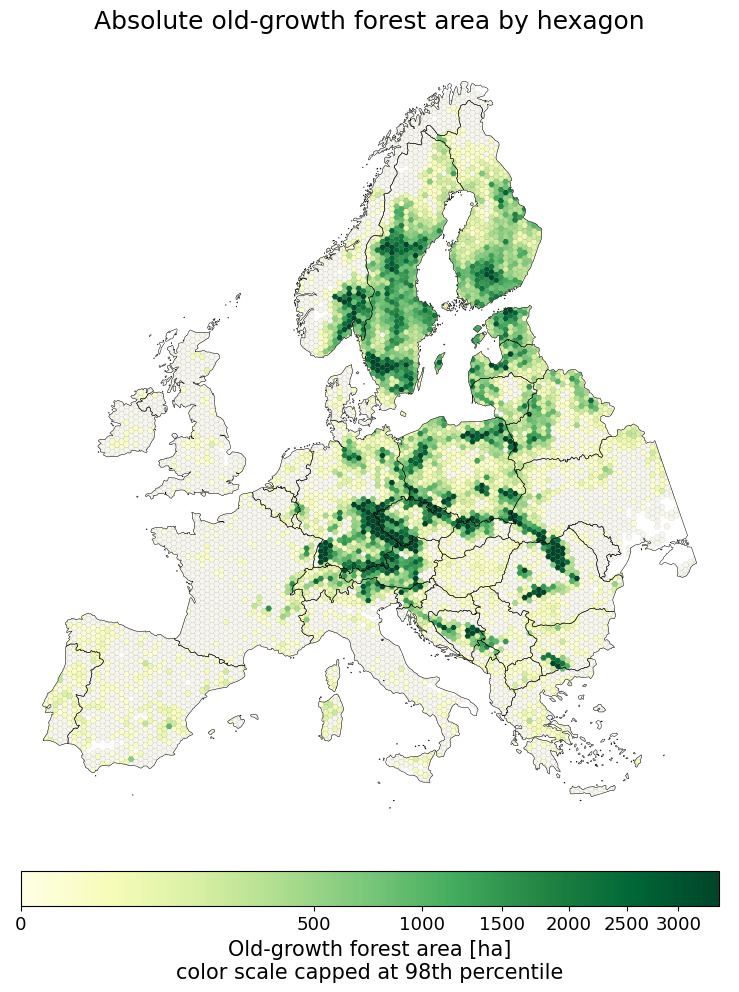

Saved absolute hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.png
Saved absolute hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.svg


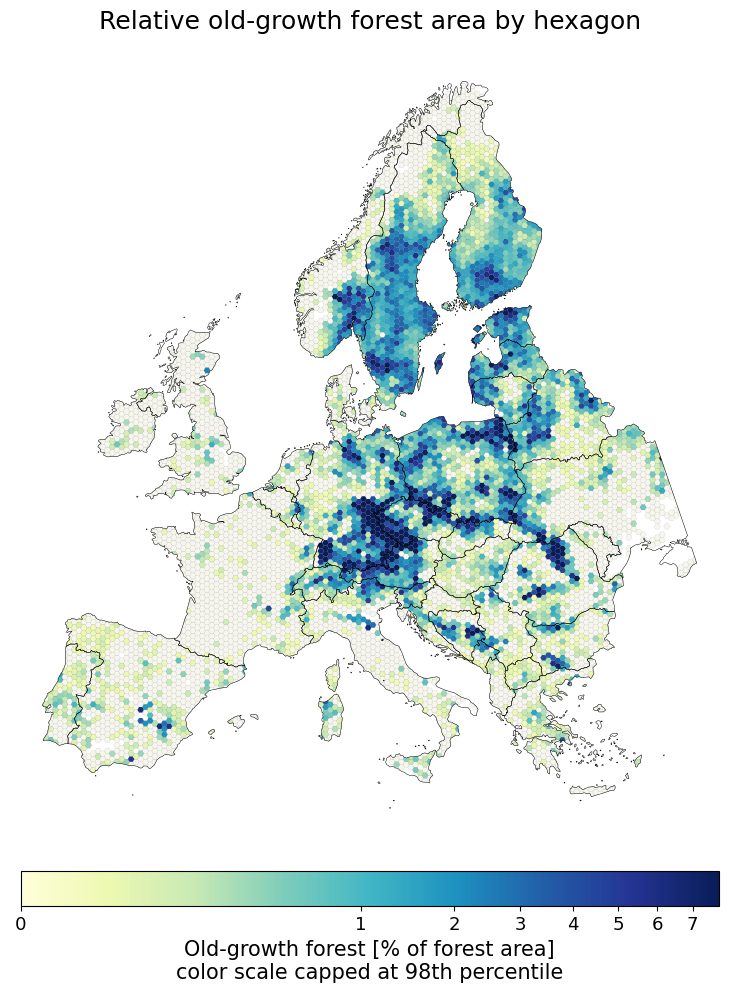

Saved relative hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.png
Saved relative hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.svg


In [93]:
# -------------------------------------------------
# PLOTTING ONLY
# Assumes:
# - hexes_plot already exists
# - countries_eur already exists
# - out_dir already exists
# -------------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -------------------------------------------------
# COLOR NORMALIZATION
# -------------------------------------------------
# Absolute Fläche: perzentilbasiert, damit wenige Hotspots nicht alles dominieren
abs_vmin = 0
abs_vmax = np.nanpercentile(hexes_plot["oldgrowth_area_ha"], 98)
abs_norm = mpl.colors.PowerNorm(gamma=0.45, vmin=abs_vmin, vmax=abs_vmax)
abs_cmap = plt.get_cmap("YlGn")

# Relative Fläche: ebenfalls gestreckt
rel_vmin = 0
rel_vmax = np.nanpercentile(hexes_plot["oldgrowth_share_percent"], 98)
rel_norm = mpl.colors.PowerNorm(gamma=0.35, vmin=rel_vmin, vmax=rel_vmax)
rel_cmap = plt.get_cmap("YlGnBu")

# Für Darstellung Werte kappen, Daten bleiben unverändert
hexes_plot["oldgrowth_area_ha_plot"] = hexes_plot["oldgrowth_area_ha"].clip(upper=abs_vmax)
hexes_plot["oldgrowth_share_percent_plot"] = hexes_plot["oldgrowth_share_percent"].clip(upper=rel_vmax)

# -------------------------------------------------
# FONT SETTINGS
# -------------------------------------------------
title_size = 18
legend_label_size = 15
legend_tick_size = 13

# -------------------------------------------------
# PLOT 1: ABSOLUTE OLD-GROWTH AREA PER HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_abs = hexes_plot[
    (hexes_plot["oldgrowth_area_ha"].isna()) |
    (hexes_plot["oldgrowth_area_ha"] <= 0)
].copy()

hexes_pos_abs = hexes_plot[
    (hexes_plot["oldgrowth_area_ha"].notna()) &
    (hexes_plot["oldgrowth_area_ha"] > 0)
].copy()

if len(hexes_zero_abs) > 0:
    hexes_zero_abs.plot(
        color="#f6f6ee",
        linewidth=0.05,
        edgecolor="0.3",
        ax=ax,
        zorder=1
    )

hexes_pos_abs.plot(
    column="oldgrowth_area_ha_plot",
    cmap=abs_cmap,
    norm=abs_norm,
    linewidth=0.05,
    edgecolor="0.1",
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.35,
    zorder=3
)

sm_abs = mpl.cm.ScalarMappable(cmap=abs_cmap, norm=abs_norm)
sm_abs.set_array([])

cbar = fig.colorbar(
    sm_abs,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    "Old-growth forest area [ha]\ncolor scale capped at 98th percentile",
    fontsize=legend_label_size
)
cbar.ax.tick_params(labelsize=legend_tick_size)

ax.set_title("Absolute old-growth forest area by hexagon", fontsize=title_size, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_abs = os.path.join(out_dir, "old_growth_absolute_area_by_small_clipped_hexagon_map.png")
out_svg_abs = os.path.join(out_dir, "old_growth_absolute_area_by_small_clipped_hexagon_map.svg")

fig.savefig(out_png_abs, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_abs, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved absolute hex map PNG:", out_png_abs)
print("Saved absolute hex map SVG:", out_svg_abs)

# -------------------------------------------------
# PLOT 2: RELATIVE OLD-GROWTH SHARE PER HEXAGON
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_rel = hexes_plot[
    (hexes_plot["oldgrowth_share_percent"].isna()) |
    (hexes_plot["oldgrowth_share_percent"] <= 0)
].copy()

hexes_pos_rel = hexes_plot[
    (hexes_plot["oldgrowth_share_percent"].notna()) &
    (hexes_plot["oldgrowth_share_percent"] > 0)
].copy()

if len(hexes_zero_rel) > 0:
    hexes_zero_rel.plot(
        color="#f6f6ee",
        linewidth=0.05,
        edgecolor="0.3",
        ax=ax,
        zorder=1
    )

hexes_pos_rel.plot(
    column="oldgrowth_share_percent_plot",
    cmap=rel_cmap,
    norm=rel_norm,
    linewidth=0.05,
    edgecolor="0.1",
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.35,
    zorder=3
)

sm_rel = mpl.cm.ScalarMappable(cmap=rel_cmap, norm=rel_norm)
sm_rel.set_array([])

cbar = fig.colorbar(
    sm_rel,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    "Old-growth forest [% of forest area]\ncolor scale capped at 98th percentile",
    fontsize=legend_label_size
)
cbar.ax.tick_params(labelsize=legend_tick_size)

ax.set_title("Relative old-growth forest area by hexagon", fontsize=title_size, pad=12)
ax.set_axis_off()

plt.tight_layout()

out_png_rel = os.path.join(out_dir, "old_growth_relative_share_by_small_clipped_hexagon_map.png")
out_svg_rel = os.path.join(out_dir, "old_growth_relative_share_by_small_clipped_hexagon_map.svg")

fig.savefig(out_png_rel, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_rel, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved relative hex map PNG:", out_png_rel)
print("Saved relative hex map SVG:", out_svg_rel)

Countries in data but without map pie: []


/tmp/ipykernel_3922061/2352663509.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


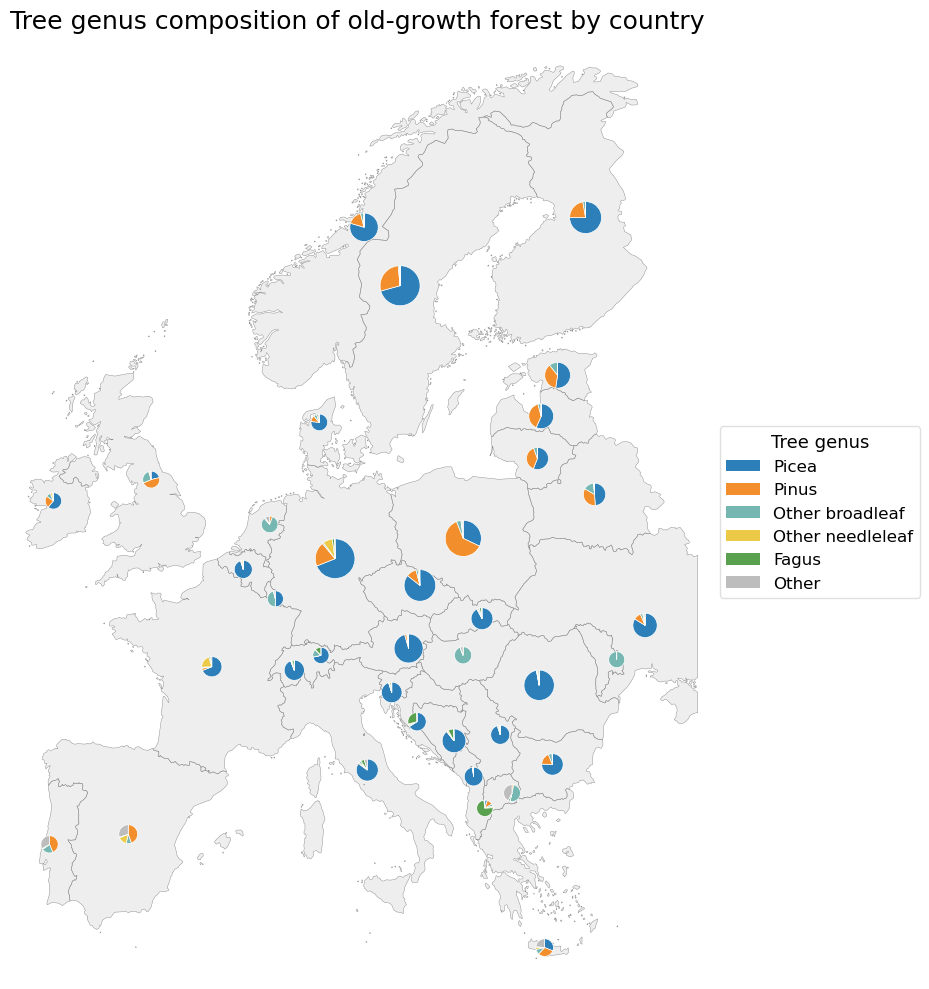

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_country_pie_map_fixed_allcountries.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_country_pie_map_fixed_allcountries.svg


In [109]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import box

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

country_name_col = "NAME_ENGL"

exclude_russia = True
exclude_no_trees = True

top_n_genera = 5
top_n_countries = None   # show all countries

# Larger pies
min_size = 0.2
max_size = 0.5

genus_colors = {
    "Picea": "#2C7FB8",
    "Pinus": "#F28E2B",
    "Fagus": "#59A14F",
    "Quercus": "#E15759",
    "Larix": "#B07AA1",
    "Other broadleaf": "#76B7B2",
    "Other needleleaf": "#EDC948",
    "Other": "#BDBDBD"
}

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom", "Vatican"
]

mainland_bbox_4326 = box(-11, 34, 35, 72)

# -------------------------------------------------
# PREPARE DATA: COUNTRY x GENUS
# -------------------------------------------------
df_plot = df_gc.copy()

df_plot["country"] = df_plot["country"].astype(str).str.strip()
df_plot["genus"] = df_plot["genus"].astype(str).str.strip()

if exclude_no_trees:
    df_plot = df_plot[df_plot["genus"] != "No trees"].copy()

if exclude_russia:
    df_plot = df_plot[df_plot["country"] != "Russian Federation"].copy()

top_genera = (
    df_plot.groupby("genus")["area_ha"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n_genera)
    .index
    .tolist()
)

df_plot["genus_plot"] = np.where(
    df_plot["genus"].isin(top_genera),
    df_plot["genus"],
    "Other"
)

df_country_genus = (
    df_plot
    .groupby(["country", "genus_plot"], as_index=False)["area_ha"]
    .sum()
)

df_country_total = (
    df_country_genus
    .groupby("country", as_index=False)["area_ha"]
    .sum()
    .rename(columns={"area_ha": "total_oldgrowth_ha"})
)

if top_n_countries is not None:
    top_countries = (
        df_country_total
        .sort_values("total_oldgrowth_ha", ascending=False)
        .head(top_n_countries)["country"]
        .tolist()
    )

    df_country_genus = df_country_genus[
        df_country_genus["country"].isin(top_countries)
    ].copy()

    df_country_total = df_country_total[
        df_country_total["country"].isin(top_countries)
    ].copy()

pie_table = (
    df_country_genus
    .pivot(index="country", columns="genus_plot", values="area_ha")
    .fillna(0)
)

genus_order = [g for g in top_genera if g in pie_table.columns]
if "Other" in pie_table.columns:
    genus_order = genus_order + ["Other"]

pie_table = pie_table[genus_order]

# -------------------------------------------------
# PREPARE COUNTRY MAP
# -------------------------------------------------
countries_map = countries.copy()
countries_map["country"] = countries_map[country_name_col].astype(str).str.strip()

countries_map = countries_map[
    countries_map["country"].isin(european_countries)
].copy()

if exclude_russia:
    countries_map = countries_map[
        countries_map["country"] != "Russian Federation"
    ].copy()

countries_map = countries_map[
    countries_map.geometry.notna() &
    ~countries_map.geometry.is_empty
].copy()

countries_map["geometry"] = countries_map.geometry.make_valid()
countries_map = countries_map.to_crs(4326)

# Temporarily explode to remove overseas parts
countries_parts = countries_map.explode(index_parts=False).reset_index(drop=True)

rep = countries_parts.representative_point()

keep = (
    (rep.x >= -11) &
    (rep.x <= 35) &
    (rep.y >= 34) &
    (rep.y <= 72)
)

countries_parts = countries_parts.loc[keep].copy()

bbox_gdf = gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)
countries_parts = gpd.clip(countries_parts, bbox_gdf)

# Dissolve back to one geometry per country
countries_map = countries_parts.dissolve(by="country", as_index=False)

countries_map = countries_map.merge(
    df_country_total,
    on="country",
    how="left"
)

countries_with_data = countries_map[
    countries_map["total_oldgrowth_ha"].notna()
].copy()

if len(countries_with_data) == 0:
    raise ValueError("No countries with matched old-growth data found.")

# Representative points
points = countries_with_data.representative_point()
countries_with_data["x"] = points.x
countries_with_data["y"] = points.y

# -------------------------------------------------
# PIE SIZE SCALING
# -------------------------------------------------
vals = countries_with_data["total_oldgrowth_ha"].values.astype(float)

vals_sqrt = np.sqrt(vals)
vmin = vals_sqrt.min()
vmax = vals_sqrt.max()

if vmax == vmin:
    countries_with_data["pie_size"] = (min_size + max_size) / 2
else:
    countries_with_data["pie_size"] = min_size + (
        (vals_sqrt - vmin) / (vmax - vmin)
    ) * (max_size - min_size)

# -------------------------------------------------
# MANUAL OFFSETS FOR CROWDED REGIONS
# values are lon/lat shifts
# -------------------------------------------------
offsets = {
    "Belgium": (-0.6, 0.15),
    "Netherlands": (0.6, 0.4),
    "Luxembourg": (0.35, -0.35),
    "Switzerland": (-0.7, -0.25),
    "Austria": (0.7, -0.25),
    "Czechia": (0.7, 0.2),
    "Slovakia": (0.8, 0.0),
    "Slovenia": (-0.3, -0.5),
    "Croatia": (0.7, -0.3),
    "Bosnia and Herzegovina": (0.55, -0.2),
    "Serbia": (0.6, -0.1),
    "Montenegro": (0.55, -0.45),
    "Kosovo": (0.55, -0.2),
    "Albania": (0.6, -0.2),
    "North Macedonia": (0.7, -0.05),
    "Moldova": (0.7, 0.0),
    "Portugal": (-0.5, -0.1),
    "Ireland": (-0.4, 0.0),
    "Denmark": (0.2, 0.4)
}

for country, (dx, dy) in offsets.items():
    idx = countries_with_data["country"] == country
    countries_with_data.loc[idx, "x"] += dx
    countries_with_data.loc[idx, "y"] += dy

# -------------------------------------------------
# OPTIONAL DIAGNOSTIC: WHICH COUNTRIES HAVE NO PIE?
# -------------------------------------------------
missing_pies = sorted(set(df_country_total["country"]) - set(countries_with_data["country"]))
print("Countries in data but without map pie:", missing_pies)

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

countries_map.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="white",
    linewidth=0.5,
    zorder=1
)

countries_map.boundary.plot(
    ax=ax,
    color="0.55",
    linewidth=0.35,
    zorder=2
)

ax.set_xlim(-11, 35)
ax.set_ylim(34, 72)
ax.set_axis_off()

ax.set_title(
    "Tree genus composition of old-growth forest by country",
    fontsize=18,
    pad=12
)

pie_colors = [genus_colors.get(g, "#cccccc") for g in genus_order]

# draw large pies first, small ones last
countries_with_data = countries_with_data.sort_values("pie_size", ascending=False)

for _, row in countries_with_data.iterrows():
    country = row["country"]

    if country not in pie_table.index:
        continue

    values = pie_table.loc[country, genus_order].values.astype(float)

    if values.sum() <= 0:
        continue

    size = row["pie_size"]

    axins = inset_axes(
        ax,
        width=size,
        height=size,
        loc="center",
        bbox_to_anchor=(row["x"], row["y"]),
        bbox_transform=ax.transData,
        borderpad=0
    )

    axins.pie(
        values,
        colors=pie_colors,
        startangle=90,
        counterclock=False,
        wedgeprops={
            "linewidth": 0.5,
            "edgecolor": "white"
        }
    )

    axins.set_aspect("equal")
    axins.set_axis_off()

# -------------------------------------------------
# LEGEND OUTSIDE THE MAP
# -------------------------------------------------
handles = [
    Patch(
        facecolor=genus_colors.get(g, "#cccccc"),
        edgecolor="none",
        label=g
    )
    for g in genus_order
]

legend = ax.legend(
    handles=handles,
    title="Tree genus",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="white",
    edgecolor="0.85",
    fontsize=12,
    title_fontsize=13
)

plt.tight_layout()

suffix = "allcountries" if top_n_countries is None else f"top{top_n_countries}"

out_png = os.path.join(out_dir, f"old_growth_country_pie_map_fixed_{suffix}.png")
out_svg = os.path.join(out_dir, f"old_growth_country_pie_map_fixed_{suffix}.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

              genus     area_ha  share_percent    color
1             Larix     4997.16       0.193467  #B07AA1
6           Quercus     6797.16       0.263155  #E15759
0             Fagus    28779.93       1.114229  #59A14F
3  Other needleleaf    44247.42       1.713060  #EDC948
2   Other broadleaf    70071.84       2.712865  #76B7B2
5             Pinus   614557.26      23.792882  #F28E2B
4             Picea  1813495.14      70.210341  #2C7FB8


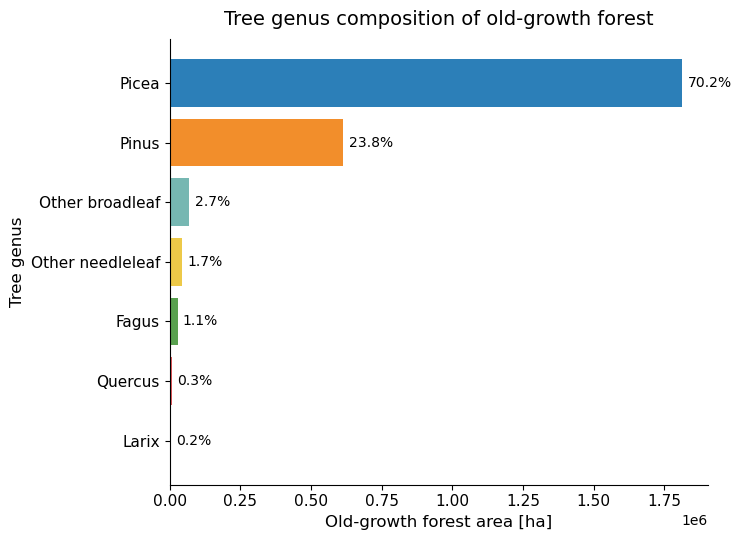

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.svg


In [111]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
out_dir = "/mnt/eo/EO4Backcasting/figures"
os.makedirs(out_dir, exist_ok=True)

exclude_no_trees = True
top_n_genera = None   # z.B. 6, oder None für alle

genus_colors = {
    "Picea": "#2C7FB8",
    "Pinus": "#F28E2B",
    "Fagus": "#59A14F",
    "Quercus": "#E15759",
    "Larix": "#B07AA1",
    "Other broadleaf": "#76B7B2",
    "Other needleleaf": "#EDC948",
    "Other": "#BDBDBD"
}

# -------------------------------------------------
# PREPARE DATA
# -------------------------------------------------
df_plot = df_gc.copy()

df_plot["genus"] = df_plot["genus"].astype(str).str.strip()

if exclude_no_trees:
    df_plot = df_plot[df_plot["genus"] != "No trees"].copy()

df_genus = (
    df_plot
    .groupby("genus", as_index=False)["area_ha"]
    .sum()
)

df_genus = df_genus.sort_values("area_ha", ascending=False).copy()

if top_n_genera is not None and len(df_genus) > top_n_genera:
    df_top = df_genus.head(top_n_genera).copy()
    rest = df_genus.iloc[top_n_genera:]["area_ha"].sum()

    if rest > 0:
        df_rest = pd.DataFrame({
            "genus": ["Other"],
            "area_ha": [rest]
        })
        df_genus = pd.concat([df_top, df_rest], ignore_index=True)
    else:
        df_genus = df_top.copy()

# Anteil berechnen
total_area = df_genus["area_ha"].sum()
df_genus["share_percent"] = df_genus["area_ha"] / total_area * 100

# Für horizontalen Plot von klein nach groß sortieren
df_genus = df_genus.sort_values("area_ha", ascending=True).copy()

# Farben zuweisen
df_genus["color"] = df_genus["genus"].map(genus_colors).fillna("#BDBDBD")

print(df_genus)

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars = ax.barh(
    df_genus["genus"],
    df_genus["area_ha"],
    color=df_genus["color"],
    edgecolor="none"
)

ax.set_xlabel("Old-growth forest area [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title("Tree genus composition of old-growth forest", fontsize=14, pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

# Labels mit Prozent und Fläche
xmax = df_genus["area_ha"].max()

for i, (_, row) in enumerate(df_genus.iterrows()):
    ax.text(
        row["area_ha"] + xmax * 0.01,
        i,
        f'{row["share_percent"]:.1f}%',
        va="center",
        fontsize=10
    )

plt.tight_layout()

out_png = os.path.join(out_dir, "old_growth_genus_barplot.png")
out_svg = os.path.join(out_dir, "old_growth_genus_barplot.svg")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)